In [21]:
import os
import pandas as pd
def get_price_his():
    country = "us"
    stock_id = "NVDA"
    path_price_his = f"{os.path.abspath(os.getcwd())}/history_data/{country}/stock_price/{stock_id}tech.csv"
    # print(path_price_his)
    df_price_his = pd.read_csv(path_price_his, encoding="utf-8")
    df_price_his["Date"] = pd.to_datetime(df_price_his["Date"], format="%Y%m%d")
    return df_price_his

price_his = get_price_his()
price_his.head()

,Date,Volume,Open,High,Low,Close,MA5,MA10,MA20,EMA5,EMA12,EMA26,DIF,MACD,RSI,Volatility,K,D
0,2020-01-21,217917000,6.1951,6.2323,6.1643,6.1985,NaN,NaN,NaN,6.198500,6.198500,6.198500,0.000000,0.000000,NaN,NaN,50.000000,50.000000
1,2020-01-22,239238680,6.2440,6.3398,6.2250,6.2513,NaN,NaN,NaN,6.216100,6.206623,6.202411,0.004212,0.000842,NaN,NaN,49.857550,49.952517
2,2020-01-23,244514440,6.2930,6.3300,6.2038,6.3215,NaN,NaN,NaN,6.251233,6.224296,6.211233,0.013064,0.003287,NaN,NaN,63.095916,54.333650
3,2020-01-24,373513560,6.4375,6.4875,6.2075,6.2620,NaN,NaN,NaN,6.254822,6.230097,6.214993,0.015104,0.005650,NaN,NaN,52.140264,53.602521
4,2020-01-27,470534000,5.9560,6.0563,5.8057,6.0050,6.20766,NaN,NaN,6.171548,6.195467,6.199438,-0.003971,0.003726,NaN,NaN,44.503992,50.569678


In [22]:
import numpy as np
from datetime import datetime

def get_sigs(df_price_his):
    sigs = []
    MOV = "EMA5"

    for date_str in df_price_his["Date"]:
        date_str = date_str.strftime("%Y%m%d")
        if datetime.strptime(date_str, "%Y%m%d") < datetime.strptime("20240201", "%Y%m%d"):
            continue
        current_index = df_price_his.index[df_price_his["Date"] == date_str].tolist()[0]
        price_t_1 = df_price_his.iloc[current_index - 1]    # t-1 個交易日的價格

        sig = 0
        if price_t_1["Close"] > price_t_1[MOV]:
            sig = 1
        elif price_t_1["Close"] <= price_t_1[MOV]:
            sig = -1

        sigs.append([date_str, sig])

    return sigs


def overnight_rtn_list(sigs, df_price_his):
    '''
        long-term investment evaluation
    '''
    rtn_list = []   # daily return list
    in_out_list_sig = []
    position = 0
    enter_price = 0
    
    for date_str, sig in sigs:

        date = pd.to_datetime(date_str, format="%Y%m%d")
        df_price = df_price_his[df_price_his["Date"] == date]

        current_index = df_price_his.index[df_price_his["Date"] == date].tolist()[0]
        price_t_1 = df_price_his.iloc[current_index - 1]    # t-1 個交易日的價格

        # print(df_price_yesterday)
        if df_price.empty:
            continue
        
        # print(date_str, sig, hold)
        # check is last day
        if date_str == sigs[-1][0]:
            # print("last day")
            if position == 1:
                # Close
                rtn = (float(df_price.iloc[0]["Close"]) - enter_price) / enter_price
                in_out_list_sig.append([date_str, "close", sig, float(df_price.iloc[0]["Close"])])
            elif position == -1:
                # Close
                rtn = (enter_price - float(df_price.iloc[0]["Close"])) / enter_price
                in_out_list_sig.append([date_str, "close", sig, float(df_price.iloc[0]["Close"])])
            elif position == 0:
                rtn = 0
            rtn_list.append([date_str, rtn])
            
            # print(rtn_list)
            # print(in_out_list_sig)
            
            return rtn_list, in_out_list_sig
        
        # print(sig, df_price.iloc[0]["Close"], df_price.iloc[0]["MA5"])
        open_price = df_price.iloc[0]["Open"]
        close_price = df_price.iloc[0]["Close"]
        if sig == 1:
            if position == 0:
                # long
                enter_price = open_price
                rtn = (close_price - enter_price) / enter_price
                in_out_list_sig.append([date_str, "enter", sig, enter_price])
                enter_price = close_price
                position = 1
            elif position == 1:
                # hold
                rtn = (float(df_price.iloc[0]["Close"]) - enter_price) / enter_price
                enter_price = float(df_price.iloc[0]["Close"])
            # elif position == -1:
            #     # Close 
            #     rtn = (enter_price - open_price) / enter_price
            #     in_out_list_sig.append([date_str, "close", sig, open_price])
            #     enter_price = 0
            #     position = 0
                
        elif sig == -1:        
            if position == 0:
                # Short
                # enter_price = open_price
                rtn = 0
                # in_out_list_sig.append([date_str, "enter", sig, enter_price])
                enter_price = close_price
                position = 0
            elif position == 1:
                # Close
                rtn = (open_price - enter_price) / enter_price
                in_out_list_sig.append([date_str, "close", sig, open_price])
                enter_price = 0
                position = 0
            # elif position == -1:
            #     # hold
            #     rtn = (enter_price - float(df_price.iloc[0]["Close"])) / enter_price
            #     enter_price = float(df_price.iloc[0]["Close"])
                
        else:
            if position == 0:
                # do nothing
                rtn = 0
            elif position == 1:
                # hold
                rtn = (float(df_price.iloc[0]["Close"]) - enter_price) / enter_price
                enter_price = float(df_price.iloc[0]["Close"])
            # elif position == -1:
            #     # hold
            #     rtn = (enter_price - float(df_price.iloc[0]["Close"])) / enter_price
            #     enter_price = float(df_price.iloc[0]["Close"])
        rtn_list.append([date_str, rtn])

def eval_onlymov(  df_price_his):
    '''
        Overnight Trade Eval : Evaluate Overnight return based on the individual
    '''
    # print(individual, end=" ")

    sigs = get_sigs(  df_price_his)
    gain = []
    loss = []
    gain_precision = []
    loss_precision = []
    accumulated_rtn_list, in_out_sig_list = overnight_rtn_list( sigs, df_price_his)
    tp = 0
    fp = 0
    tn = 0
    fn = 0
    # print(in_out_sig_list)
    
    longshort = 'none'
    enter_price = 0
    for i, (date_str, state, sig, price) in enumerate(in_out_sig_list):

        if state == "enter":
            if sig == 1:
                longshort = 'long'
            elif sig == -1:
                longshort = 'short'
            enter_price = price
            print(f"enter  {longshort} \t {date_str} {enter_price}", end="\t")  
              
        if state == "close":
            if longshort == 'long':
                print(f"close {date_str} {price}")
                rtn = (price - enter_price) / enter_price
                if rtn > 0:
                    tp += 1
                    gain.append(rtn)
                    gain_precision.append(rtn)
                else:
                    fp += 1
                    loss.append(rtn)
                    loss_precision.append(rtn)
            elif longshort == 'short':
                print(f"close {date_str} {price}")
                rtn = (enter_price - price) / enter_price
                if rtn > 0: 
                    tn += 1
                    gain.append(rtn)    
                else:
                    fn += 1
                    loss.append(rtn)
            # print(rtn)

    if tp + fp + tn + fn == 0 or tp + fp == 0 or tp + fn == 0:
        accuracy = precision = recall = ev = precision_ev = 0
    else:
        accuracy = (tp + tn) / (tp + fp + tn + fn)
        precision = tp / (tp + fp)
        recall = tp / (tp + fn)

        if len(gain) == 0 or len(loss) == 0:
            ev = 0
        else:
            ev = np.mean(gain) * accuracy + np.mean(loss) * (1 - accuracy)

        if len(gain_precision) == 0 or len(loss_precision) == 0:
            precision_ev = 0
        else:
            precision_ev = np.mean(gain_precision) * precision + np.mean(
                loss_precision
            ) * (1 - precision)

    result = {
        "tp": tp,
        "fp": fp,
        "tn": tn,
        "fn": fn,
        "avail_count": tp + fp + tn + fn,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "ev": ev,
        "precision_ev": precision_ev,
        "rtn_list": accumulated_rtn_list,
    }
    # print()

    return result

In [23]:
def get_balance_list(list_rtn, start_price):
    balance = start_price
    list_balance = []
    for rtn in list_rtn:
        balance = balance * (1 + float(rtn))
        list_balance.append(balance)
    return list_balance

In [24]:
res = eval_onlymov(price_his)
res

enter  long 	 20240202 63.974	close 20240221 68.006
enter  long 	 20240223 80.79	close 20240312 88.049
enter  long 	 20240313 91.055	close 20240315 86.93
enter  long 	 20240320 89.797	close 20240327 93.112
enter  long 	 20240412 89.699	close 20240415 89.098
enter  long 	 20240424 83.95	close 20240425 78.868
enter  long 	 20240426 83.818	close 20240502 84.449
enter  long 	 20240503 87.789	close 20240510 90.3045
enter  long 	 20240513 90.478	close 20240520 93.75
enter  long 	 20240521 93.599	close 20240624 123.24
enter  long 	 20240626 126.13	close 20240628 124.58
enter  long 	 20240705 127.38	close 20240712 128.26
enter  long 	 20240723 122.78	close 20240725 113.04
enter  long 	 20240801 117.53	close 20240802 103.76
enter  long 	 20240809 105.64	close 20240823 125.86
enter  long 	 20240826 129.57	close 20240829 121.355
enter  long 	 20240911 109.39	close 20240918 115.89
enter  long 	 20240920 117.06	close 20241002 116.44
enter  long 	 20241004 124.94	close 20241016 133.98
enter  long 	 

{'tp': 15,
 'fp': 14,
 'tn': 0,
 'fn': 0,
 'avail_count': 29,
 'accuracy': 0.5172413793103449,
 'precision': 0.5172413793103449,
 'recall': 1.0,
 'ev': 0.016209078013443855,
 'precision_ev': 0.016209078013443855,
 'rtn_list': [['20240201', 0],
  ['20240202', 0.03417013161596899],
  ['20240205', 0.047944377267230914],
  ['20240206', -0.015995499913459797],
  ['20240207', 0.02749805783973154],
  ['20240208', -0.00653361674203624],
  ['20240209', 0.03578351832971942],
  ['20240212', 0.0015942772378801534],
  ['20240213', -0.0016609456317130515],
  ['20240214', 0.02456743566992022],
  ['20240215', -0.016806495263870153],
  ['20240216', -0.0006193399212750379],
  ['20240220', -0.043532149890515494],
  ['20240221', -0.020820134769337067],
  ['20240222', 0],
  ['20240223', -0.024421339274662866],
  ['20240226', 0.003489094992197187],
  ['20240227', -0.00494360997319584],
  ['20240228', -0.01318915896875512],
  ['20240229', 0.018657533188262083],
  ['20240301', 0.040031853574678956],
  ['20240

In [25]:
list_date, list_bnh_rtn, list_stag_rtn = [], [], []
for date, rtn in res['rtn_list']:
    list_date.append(date)
    list_bnh_rtn.append(price_his[price_his['Date'].dt.strftime('%Y%m%d') == date]['Close'].values[0])
    list_stag_rtn.append(rtn)


In [26]:
# print(len(list_date), len(list_bnh_rtn), len(list_stag_rtn))
# print(list_date[:5], "/", list_bnh_rtn[:5],"/", list_stag_rtn[:5])

92.44883639649765


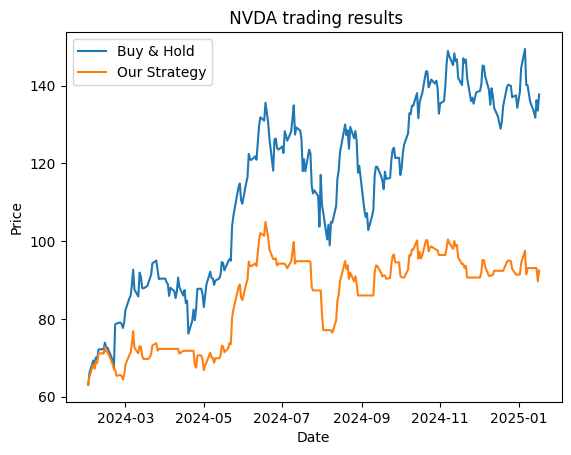

In [27]:
import matplotlib.pyplot as plt

list_stag_balance = get_balance_list(list_stag_rtn, list_bnh_rtn[0])
print(list_stag_balance[-1])

dplot = [datetime.strptime(d, '%Y%m%d').date() for d in list_date]
fig, ax = plt.subplots()
ax.set_title(f" NVDA trading results")
ax.plot(dplot, list_bnh_rtn, label="Buy & Hold")  # blue
ax.plot(dplot, list_stag_balance, label="Our Strategy")  # orange
ax.set_xlabel('Date')
ax.set_ylabel('Price')
ax.legend()


# AI

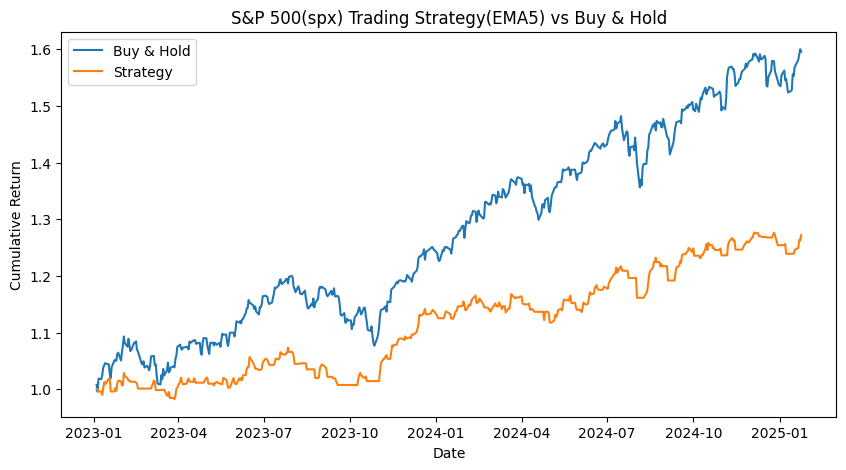

Best EMA days: 46


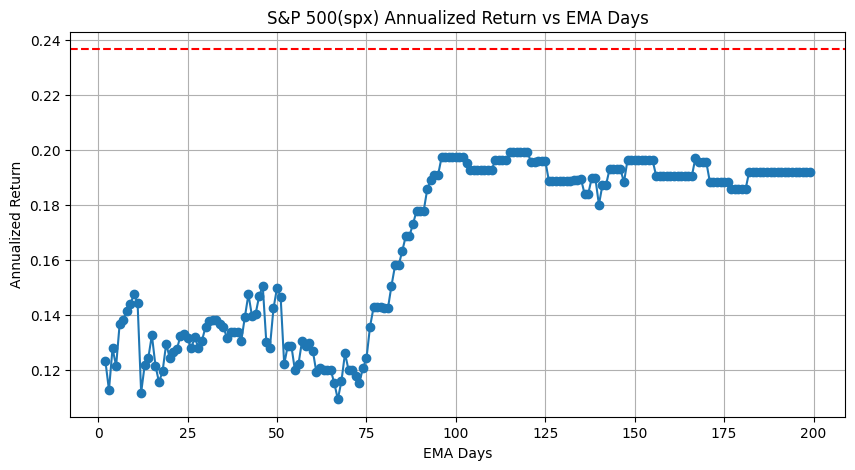

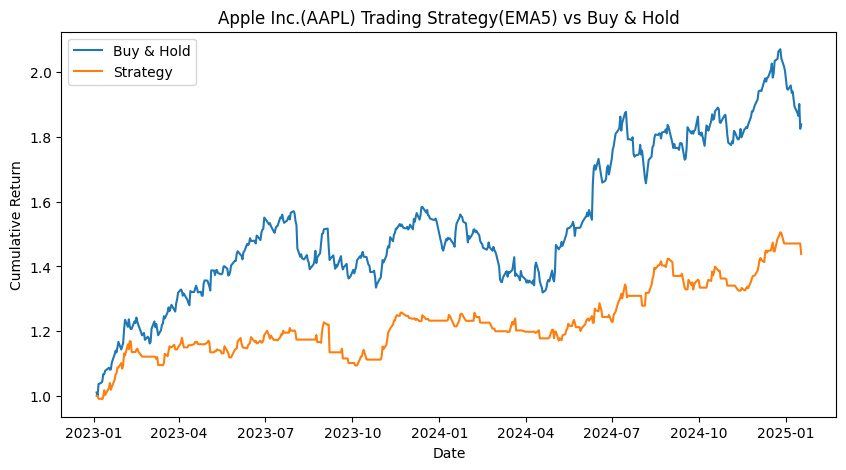

Best EMA days: 18


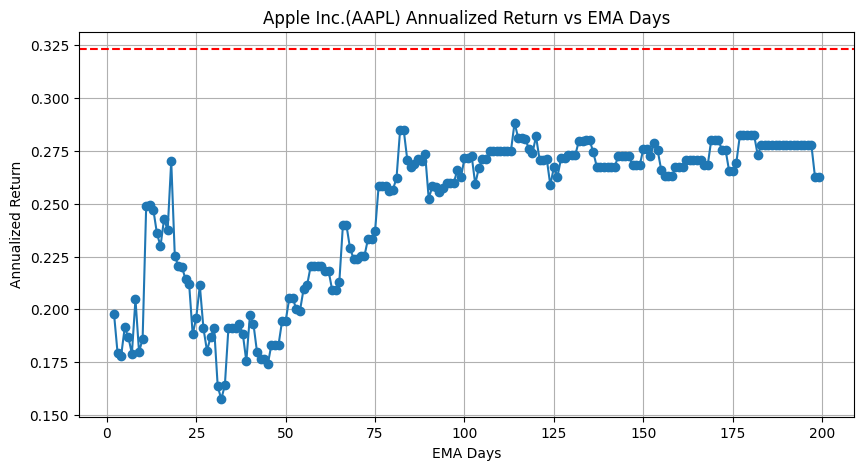

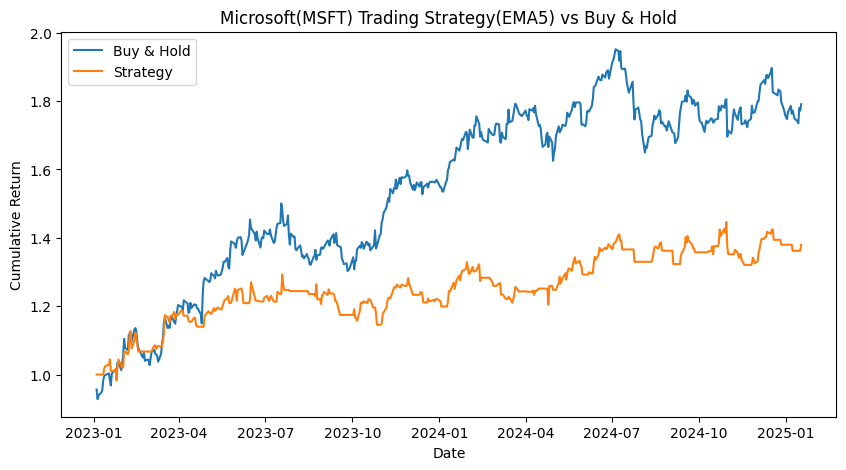

Best EMA days: 32


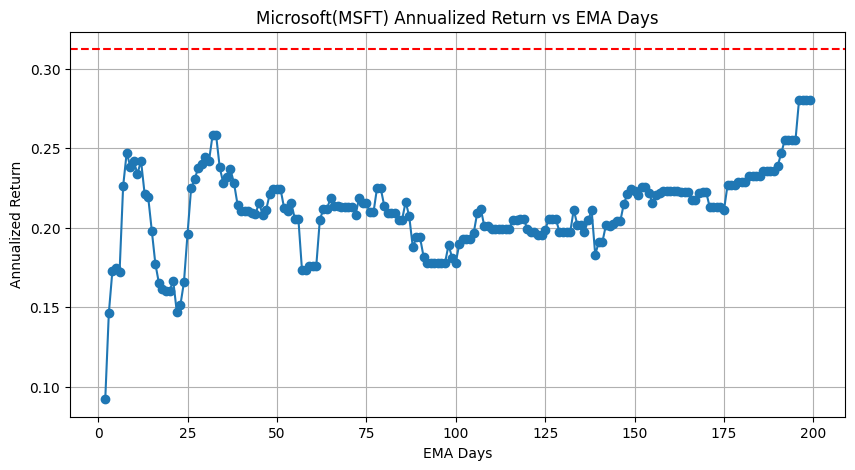

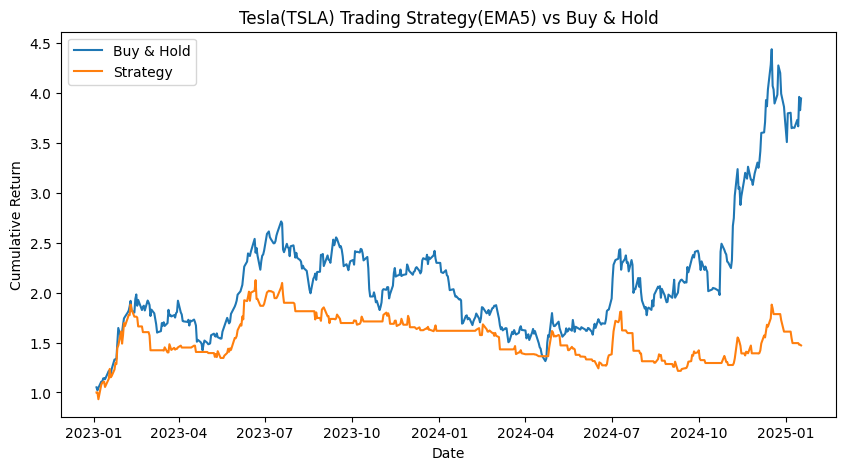

Best EMA days: 14


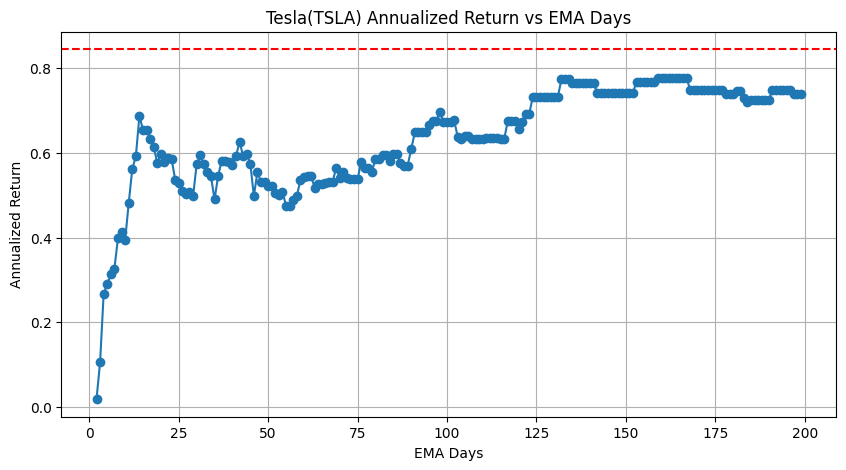

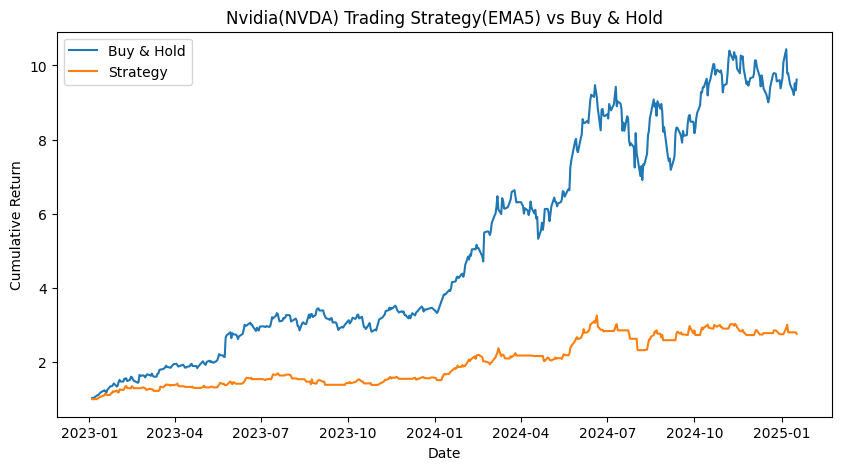

Best EMA days: 32


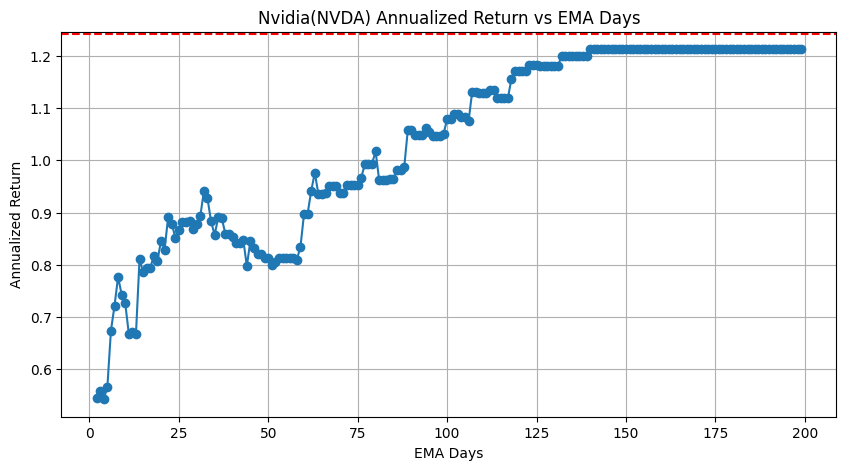

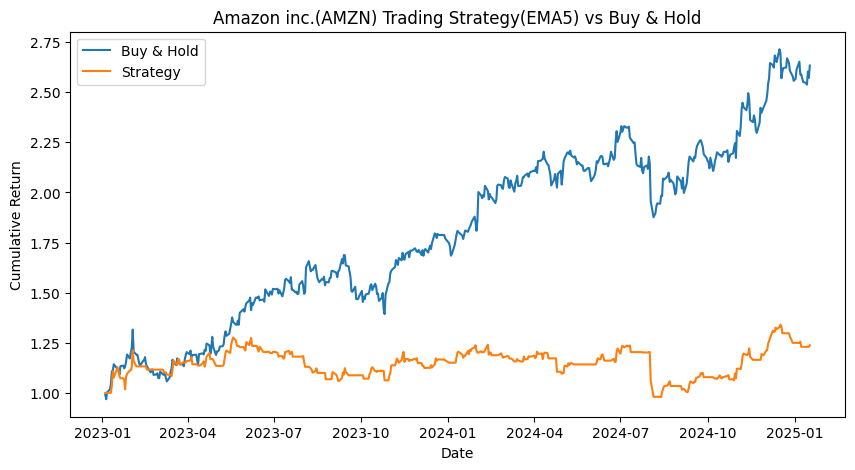

Best EMA days: 43


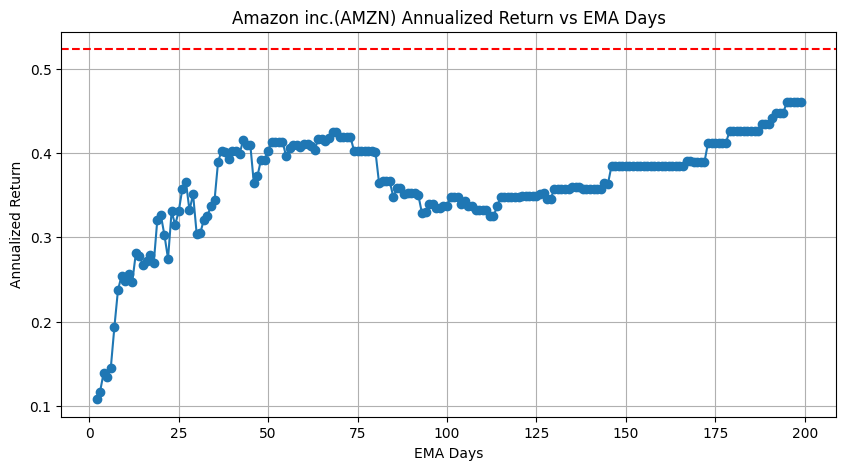

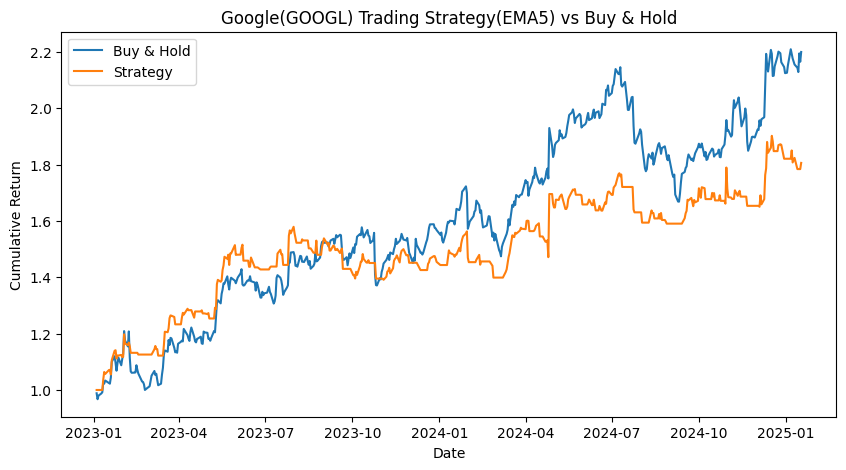

Best EMA days: 8


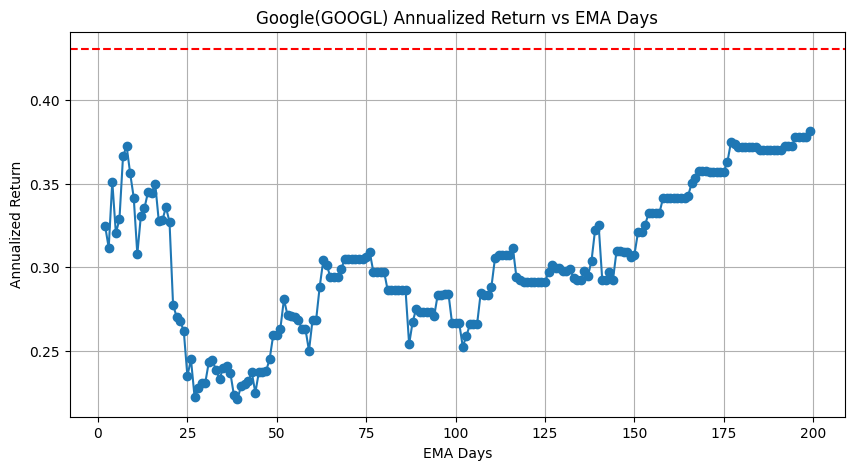

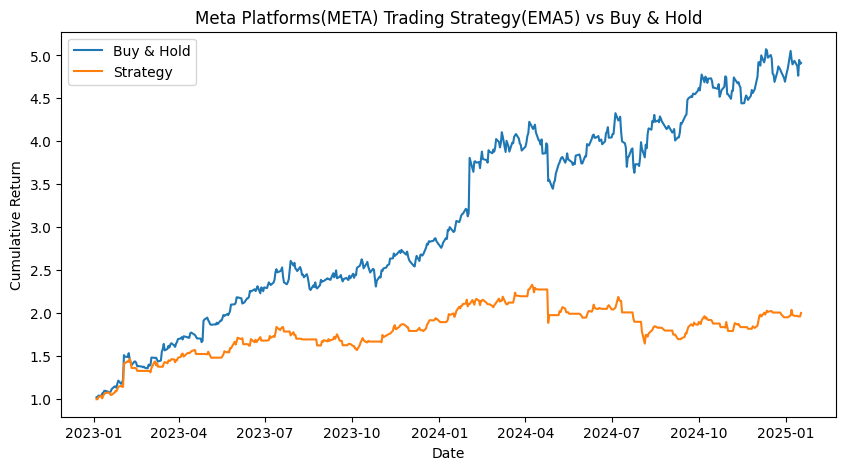

Best EMA days: 29


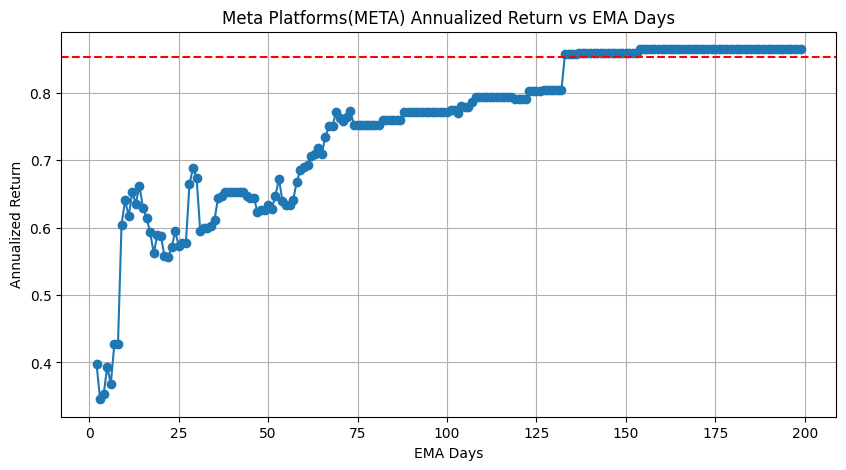

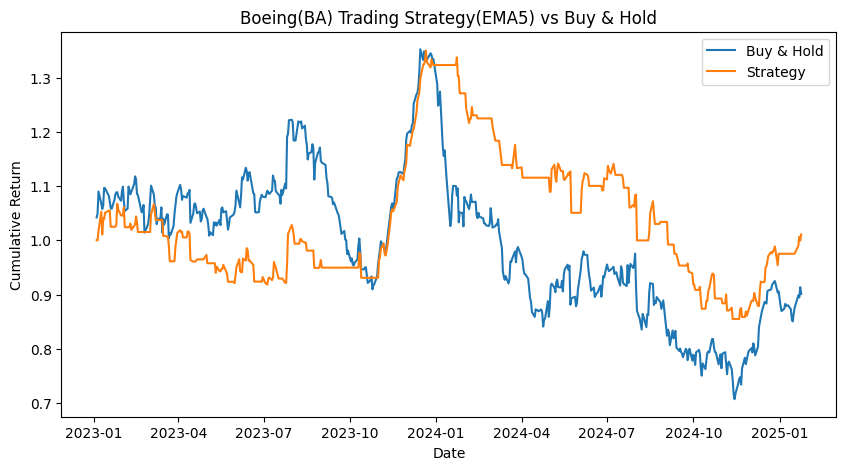

Best EMA days: 20


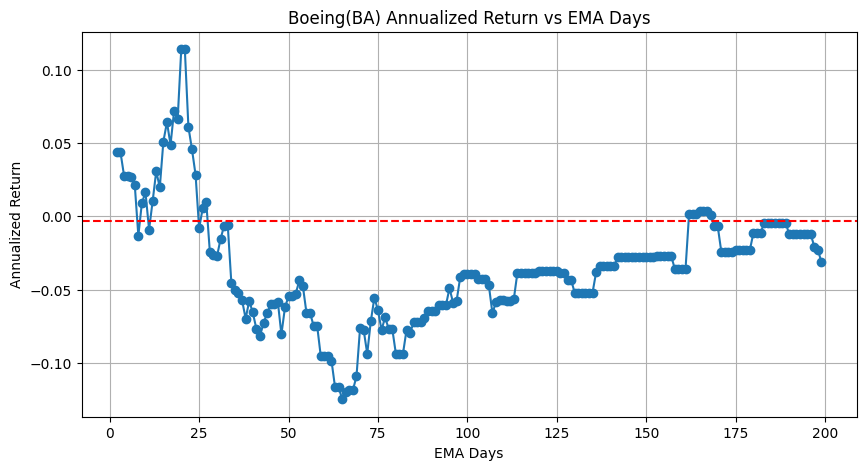

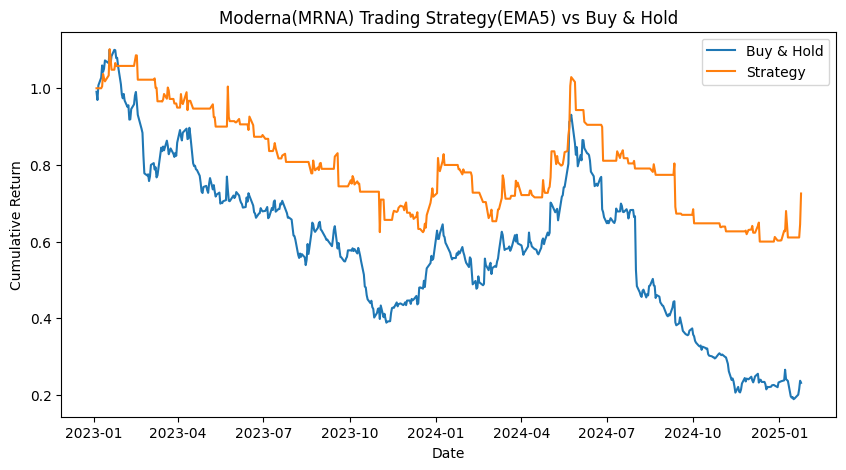

Best EMA days: 49


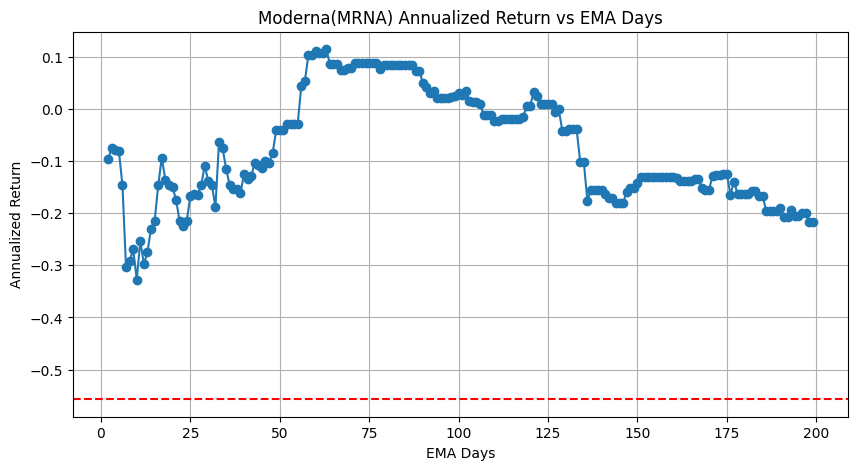

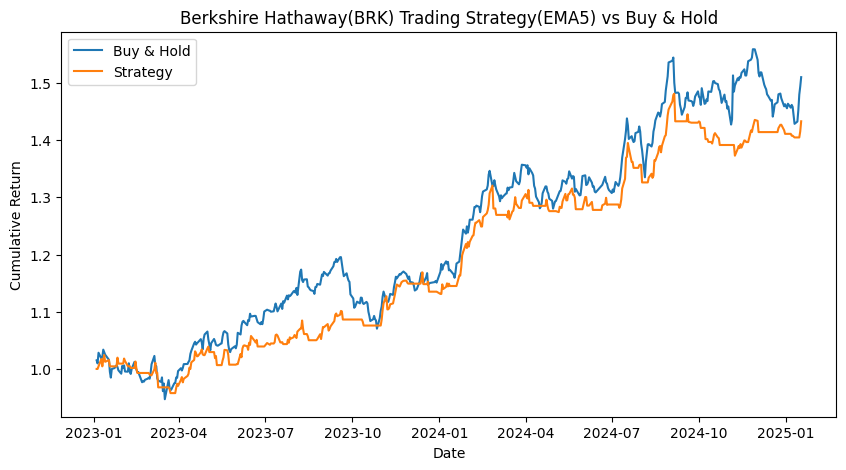

Best EMA days: 4


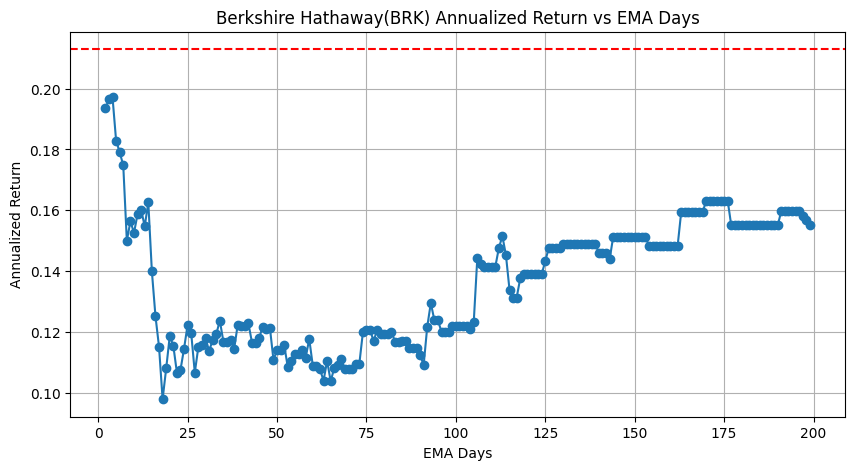

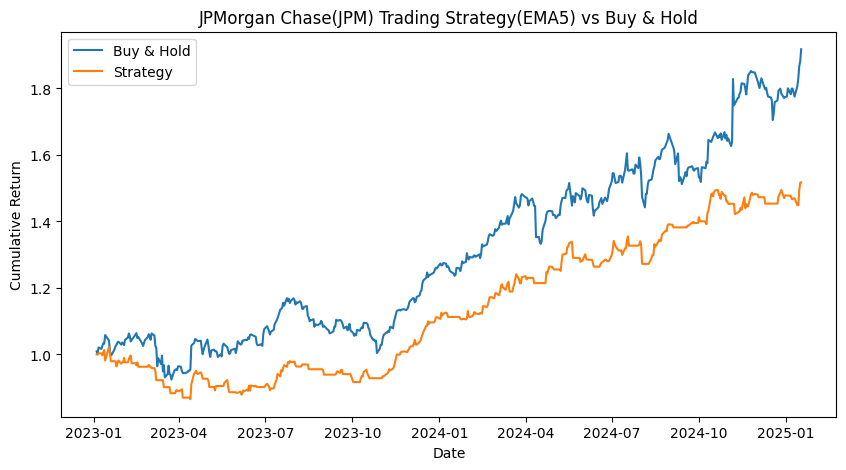

Best EMA days: 2


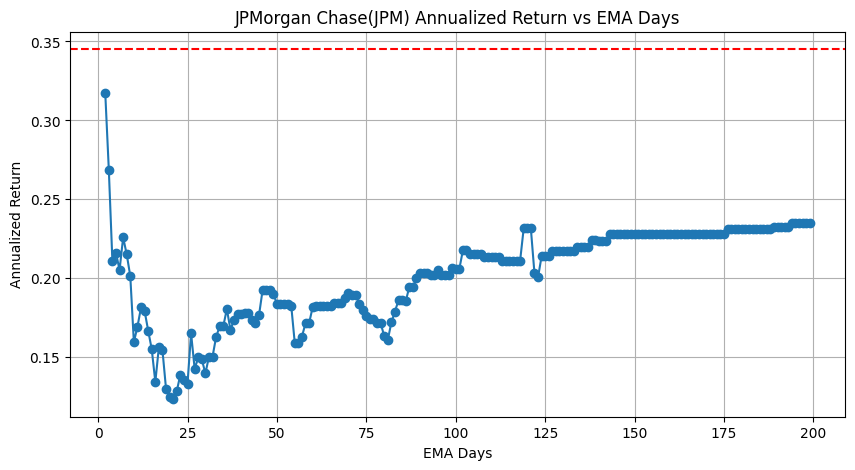

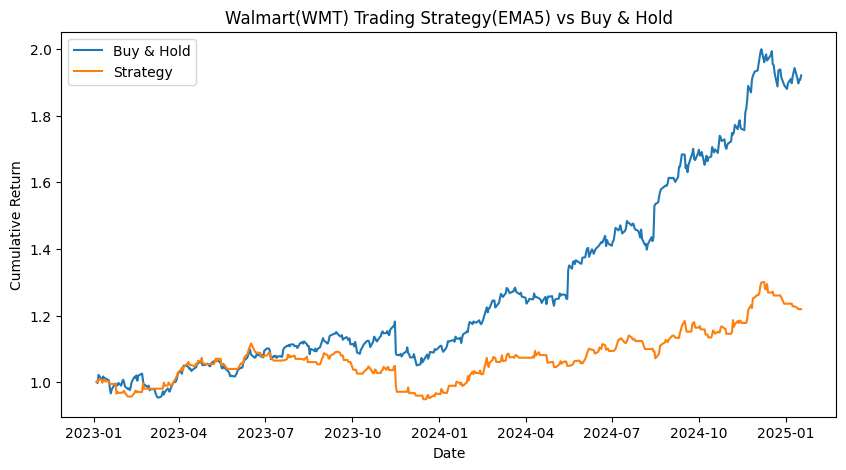

Best EMA days: 50


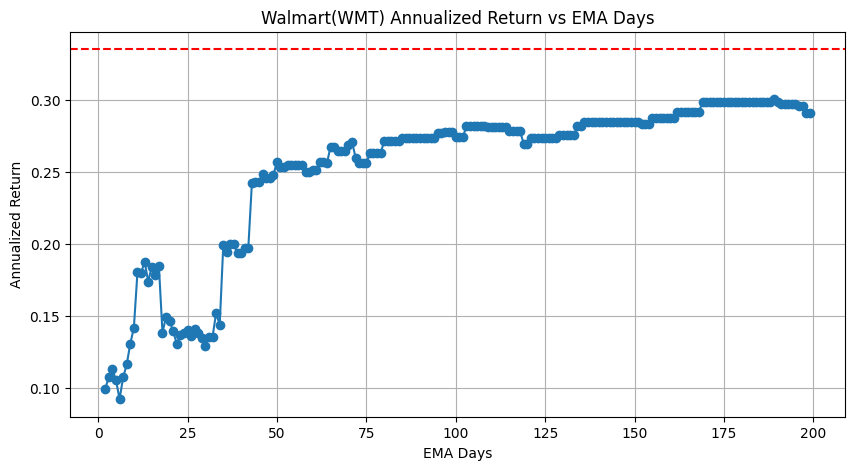

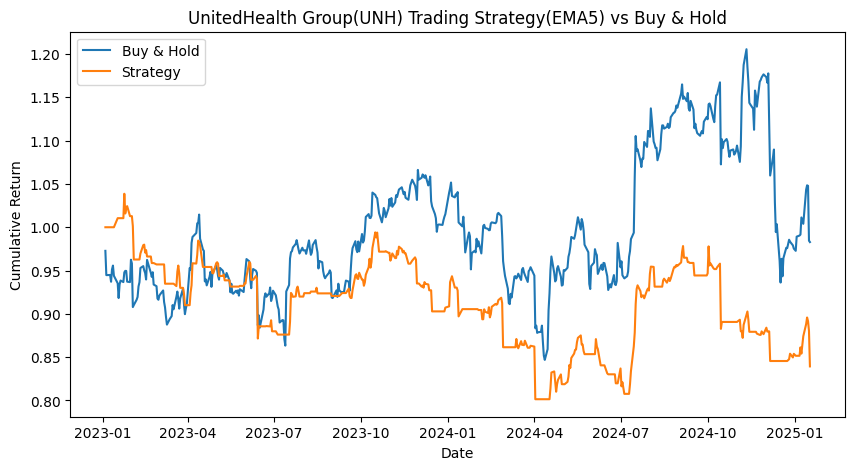

Best EMA days: 2


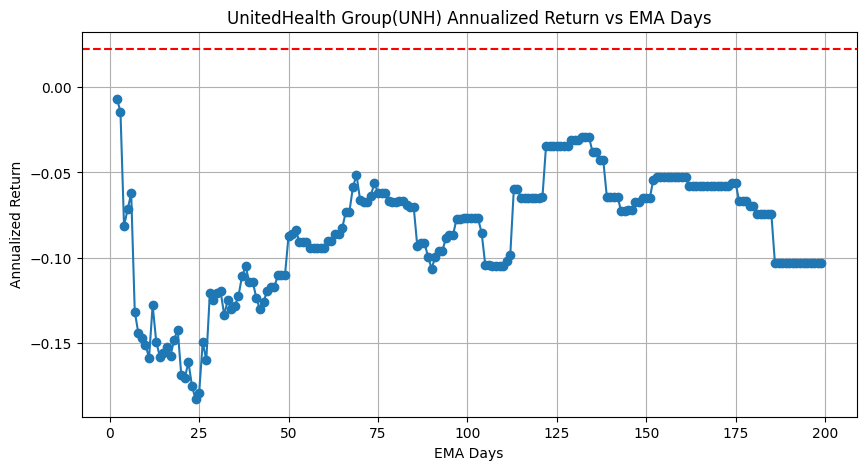

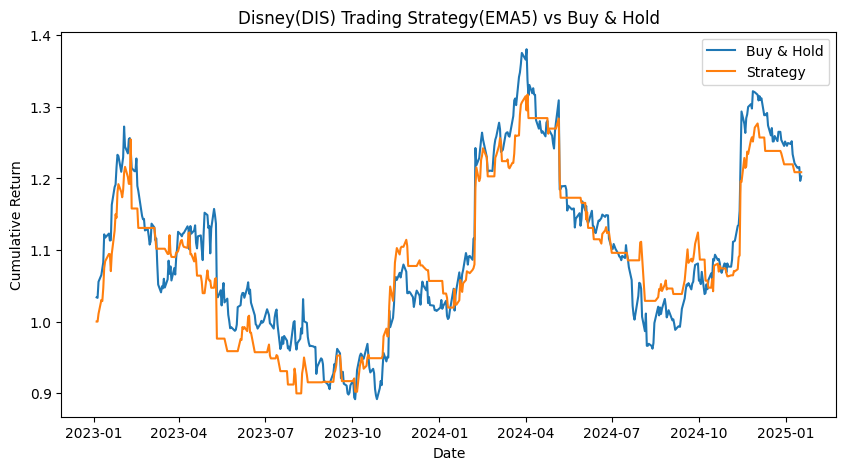

Best EMA days: 48


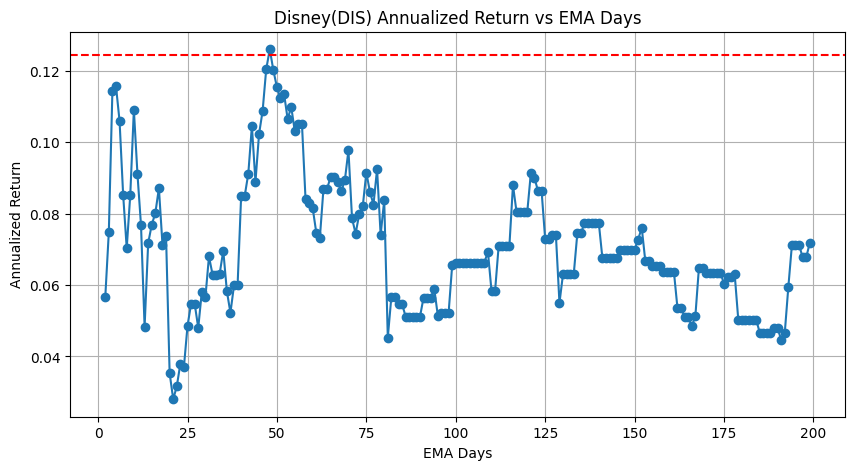

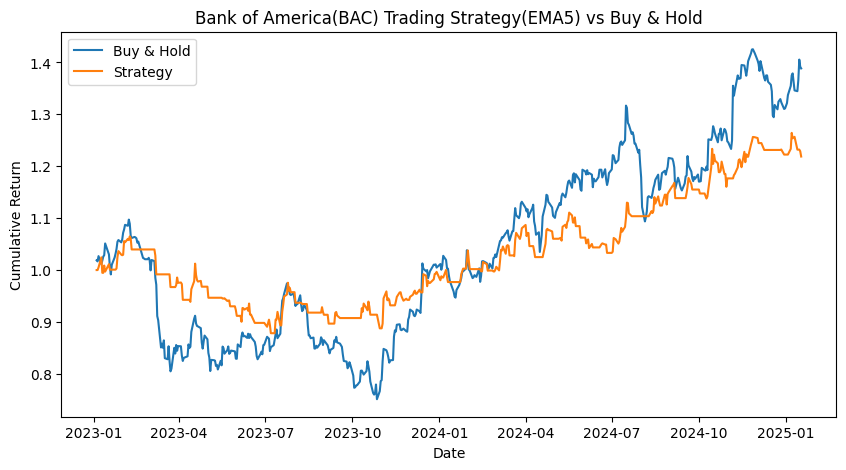

Best EMA days: 37


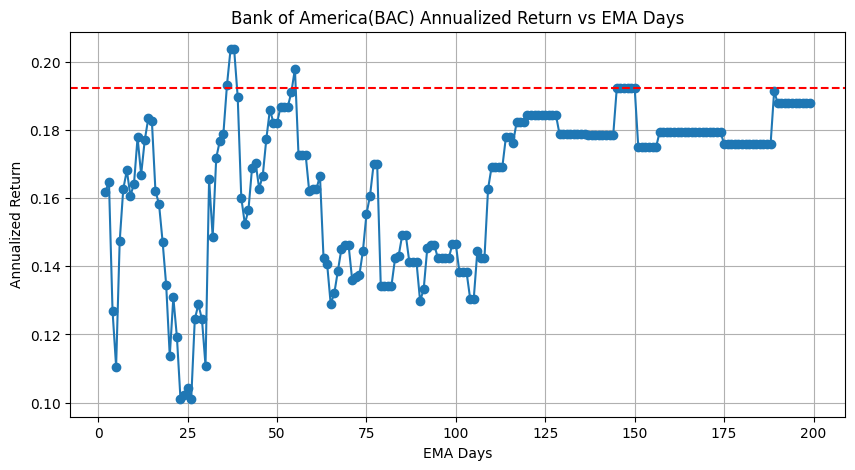

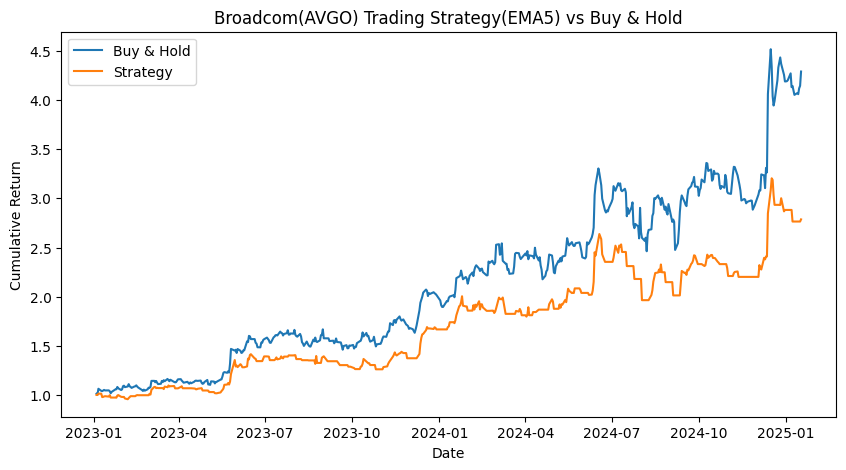

Best EMA days: 3


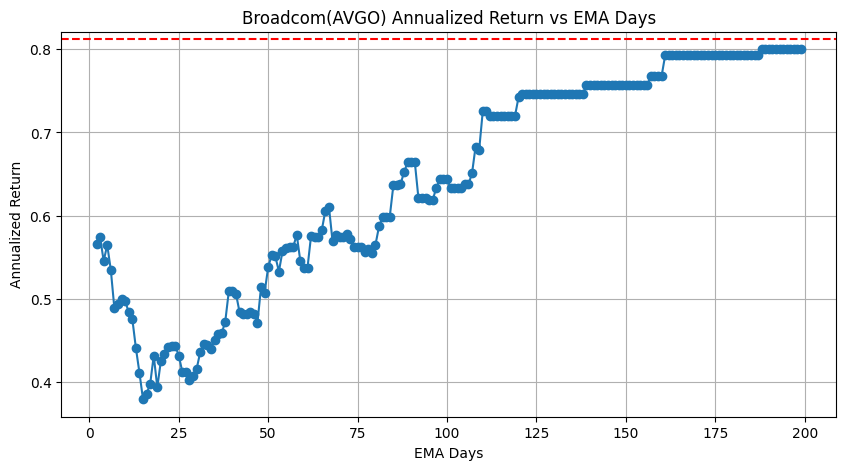

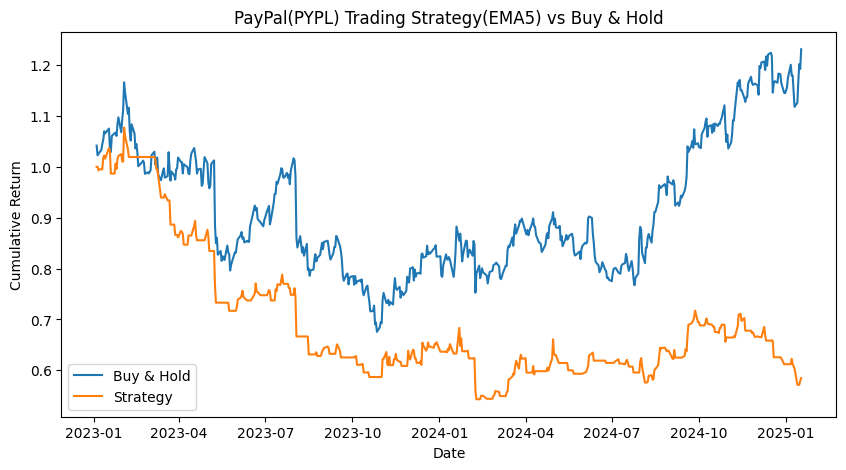

Best EMA days: 2


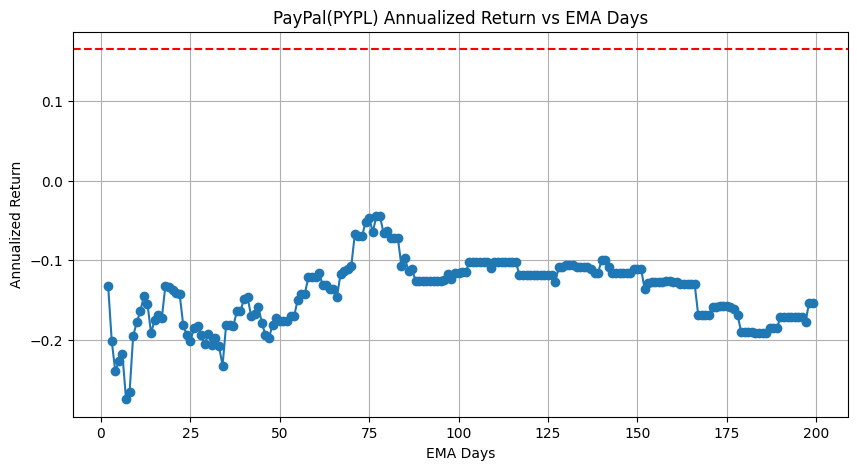

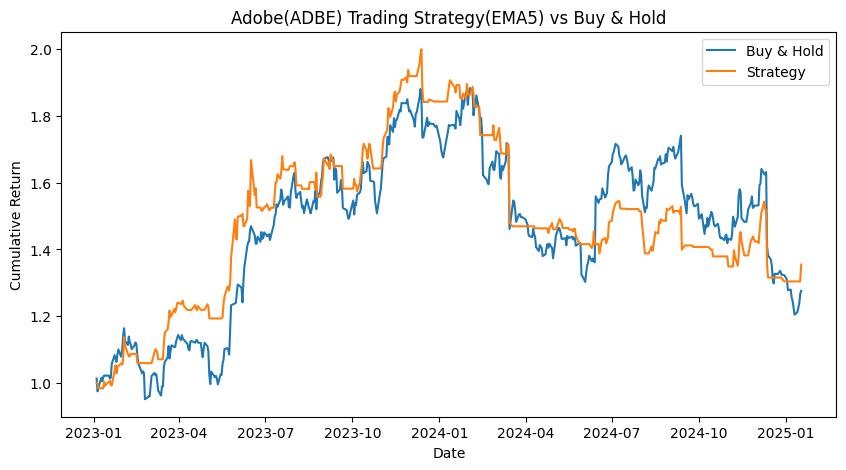

Best EMA days: 2


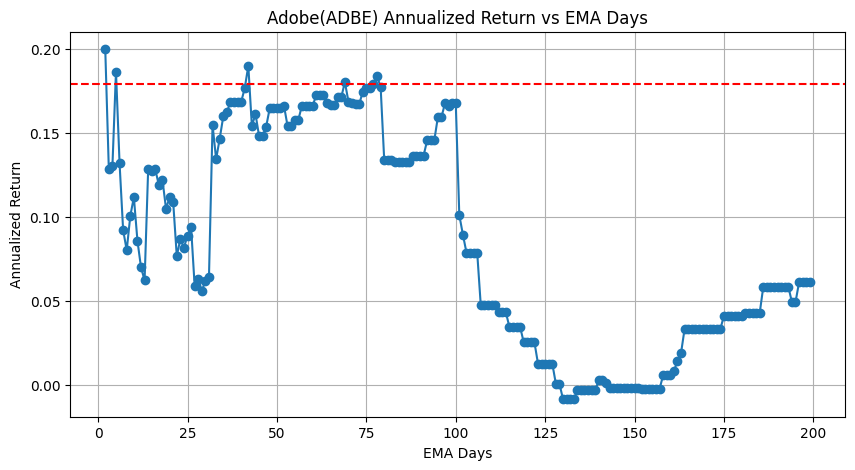

In [50]:
import pandas as pd
import os
import matplotlib.pyplot as plt

def calculate_ema(data, span):
    return data.ewm(span=span, adjust=False).mean()

def get_price_his(stock_id, country):
    path_price_his = f"{os.path.abspath(os.getcwd())}/history_data/{country}/stock_price/{stock_id}tech.csv"
    # print(path_price_his)
    df_price_his = pd.read_csv(path_price_his, encoding="utf-8")
    df_price_his["Date"] = pd.to_datetime(df_price_his["Date"], format="%Y%m%d")
    # 讓時間在 2022～2024
    df_price_his = df_price_his[df_price_his["Date"] >= "2023-01-01"]
    return df_price_his

def run_ema(stock):
    stock_id = stock[0]
    stock_name = stock[1]
    country = stock[2]
    
    price_his = get_price_his(stock_id, country)
    price_his.head()

    ema_days = range(2, 200)
    annual_returns = []

    for i in ema_days:
        # print(f'EMA {i} days')
        data = price_his.copy()
        data['Date'] = pd.to_datetime(data['Date'])  # 轉換日期格式
        data.set_index('Date', inplace=True)  # 設定日期為索引

        data['EMA'] = calculate_ema(data['Close'], span=i)  # 計算 i 日 EMA

        # 訊號判斷
        # 交易訊號：根據昨日的收盤價與 EMA 判斷持有狀態
        data['Signal'] = data['Close'].shift(1) > data['EMA'].shift(1)

        # 策略報酬：使用「當前一天的信號」決定是否在隔天開盤價買入或賣出
        data['Strategy_Return'] = data['Signal'].shift(1) * data['Open'].pct_change()

        # Buy & Hold 策略仍然使用收盤價變動
        data['Buy_and_Hold'] = data['Close'].pct_change()

        # 計算累積報酬
        data['Cumulative_Strategy'] = (1 + data['Strategy_Return']).cumprod()
        data['Cumulative_Buy_Hold'] = (1 + data['Buy_and_Hold']).cumprod()

        # 計算年化報酬率
        days_per_year = 252
        buy_and_hold_return = price_his['Close'].pct_change().mean() * days_per_year

        annualized_return = data['Strategy_Return'].mean() * days_per_year
        annual_returns.append(annualized_return)

        # print(data[['Cumulative_Strategy', 'Cumulative_Buy_Hold']].tail())

        # 繪圖
        if i == 5:
            plt.figure(figsize=(10, 5))
            plt.plot(data.index, data['Cumulative_Buy_Hold'], label='Buy & Hold', linestyle='-')
            plt.plot(data.index, data['Cumulative_Strategy'], label='Strategy', linestyle='-')
            plt.legend()
            plt.title(f'{stock_name}({stock_id}) Trading Strategy(EMA{i}) vs Buy & Hold')
            plt.xlabel('Date')
            plt.ylabel('Cumulative Return')
            plt.show()

    # print best index of annual return
    best_index = annual_returns[:50].index(max(annual_returns[:50]))
    print(f"Best EMA days: {ema_days[best_index]}")
    
    # 繪製 EMA 日數與年化報酬率的關係圖
    plt.figure(figsize=(10, 5))
    plt.plot(ema_days, annual_returns, marker='o', linestyle='-')
    plt.axhline(y=buy_and_hold_return, color='r', linestyle='--', label='Buy & Hold')  # Buy & Hold 年化報酬率
    plt.title(f'{stock_name}({stock_id}) Annualized Return vs EMA Days')
    plt.xlabel('EMA Days')
    plt.ylabel('Annualized Return')
    plt.grid()
    plt.show()
    
stocks = [
    ["spx", "S&P 500", "us"],
    ["AAPL", "Apple Inc.", "us"],
    ["MSFT", "Microsoft", "us"],
    ["TSLA", "Tesla", "us"],
    ["NVDA", "Nvidia", "us"],
    ["AMZN", "Amazon inc.", "us"],
    ["GOOGL", "Google", "us"],
    ["META", "Meta Platforms", "us"],
    ["BA", "Boeing", "us"],
    ["MRNA", "Moderna", "us"],
    
    ["BRK", "Berkshire Hathaway", "us"],
    ["JPM", "JPMorgan Chase", "us"],
    ["WMT", "Walmart", "us"],
    ["UNH", "UnitedHealth Group", "us"],
    ["DIS", "Disney", "us"],
    ["BAC", "Bank of America", "us"],
    ["AVGO", "Broadcom", "us"],
    ["PYPL", "PayPal", "us"],
    ["ADBE", "Adobe", "us"],  # 18
]
for stock in stocks:
    stock_id = stock[0]
    stock_name = stock[1]
    country = stock[2]
    # print(f"Running {stock_name} ({stock_id})")
    path_price_his = f"{os.path.abspath(os.getcwd())}/history_data/{country}/stock_price/{stock_id}tech.csv"
    if not os.path.exists(path_price_his):
        print(f"File not found: {path_price_his}")
        continue
    run_ema(stock)

# AI2

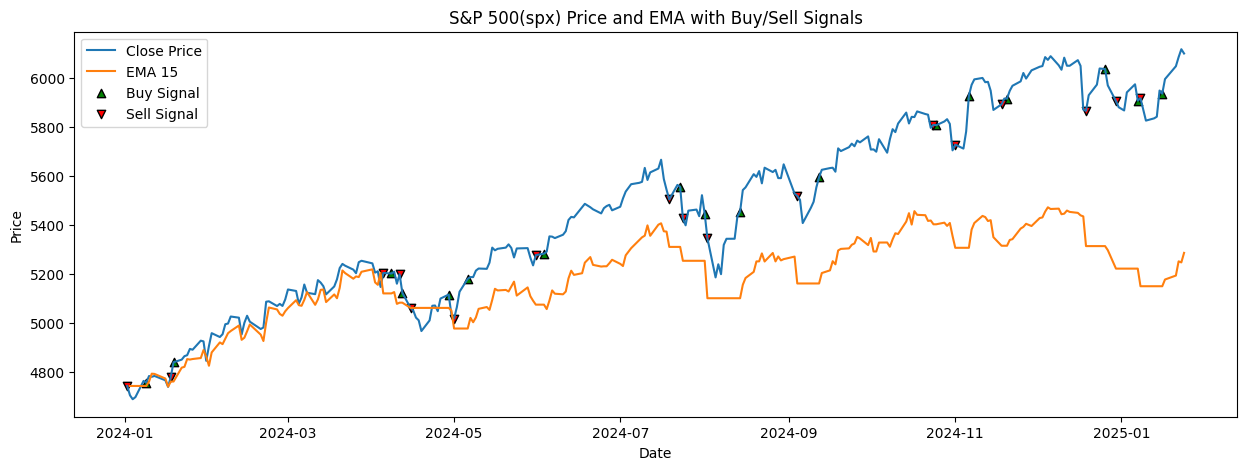

Best EMA days: 7


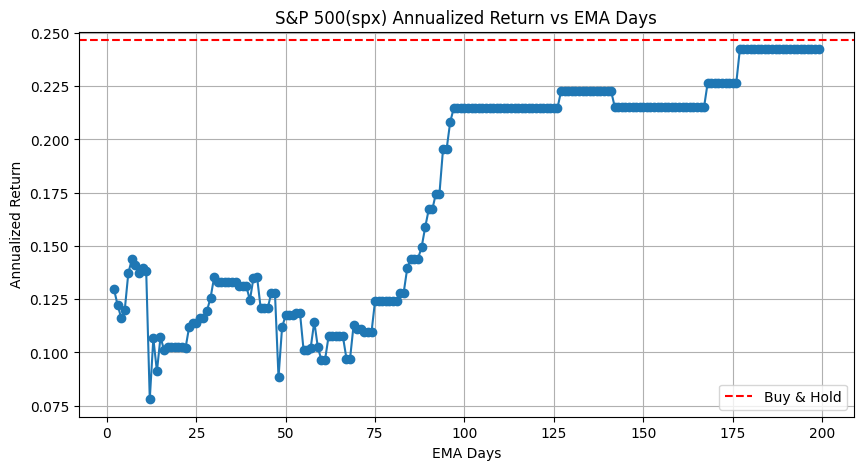

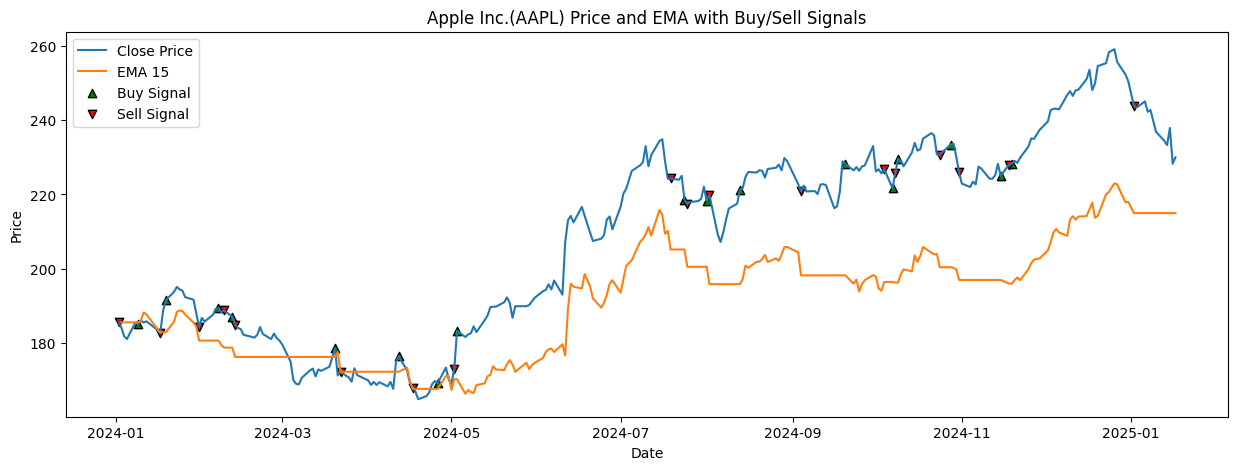

Best EMA days: 13


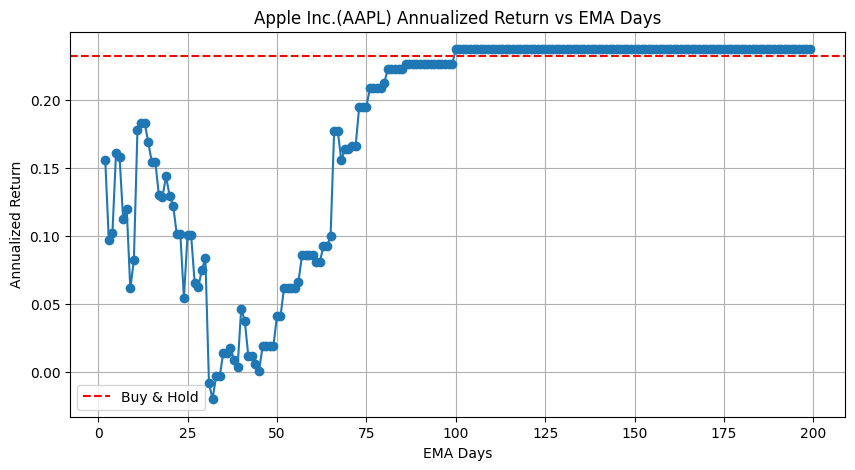

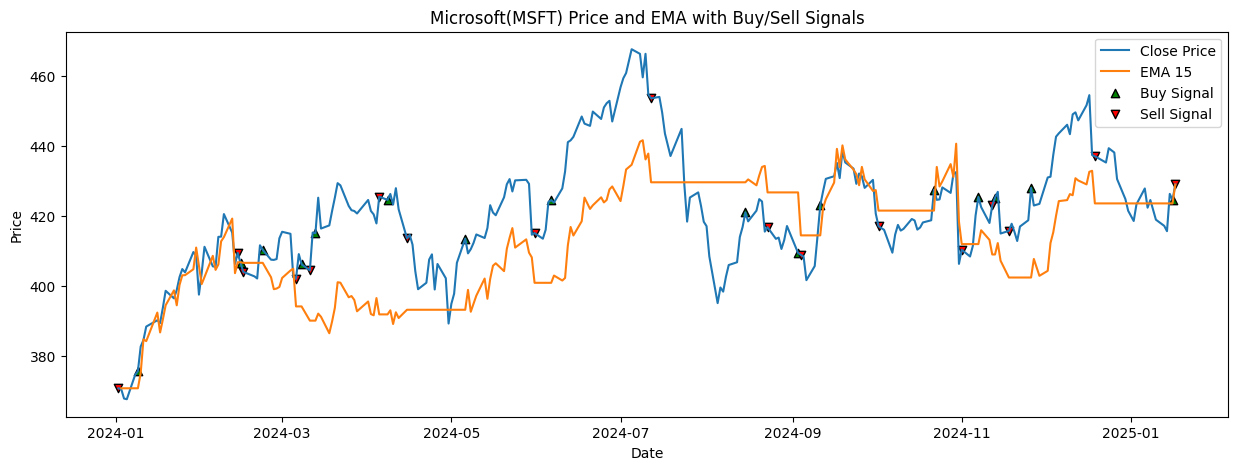

Best EMA days: 7


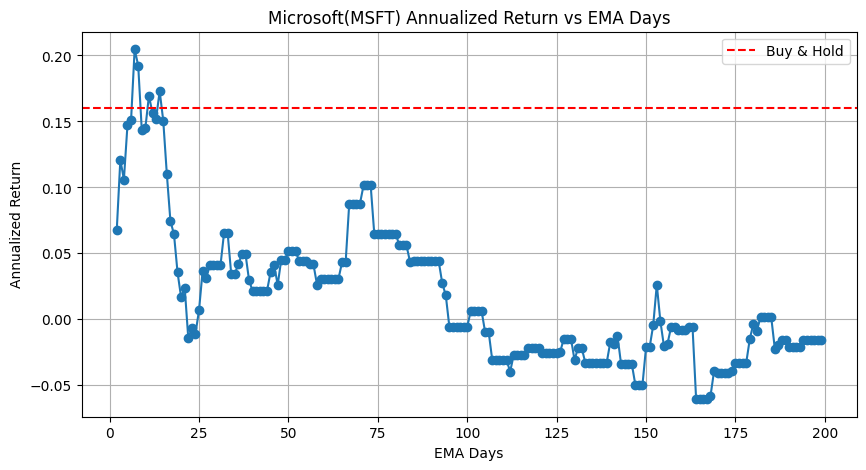

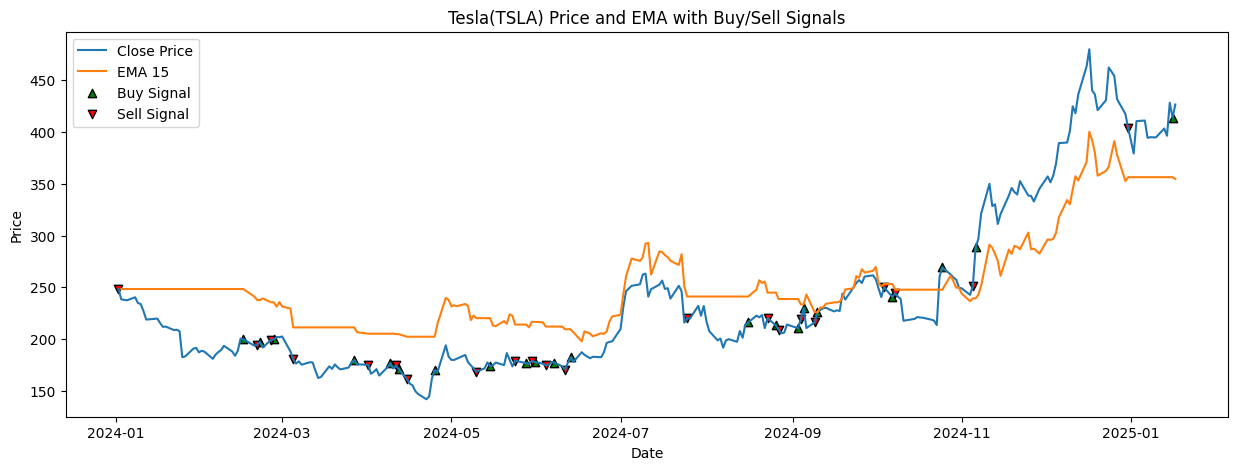

Best EMA days: 43


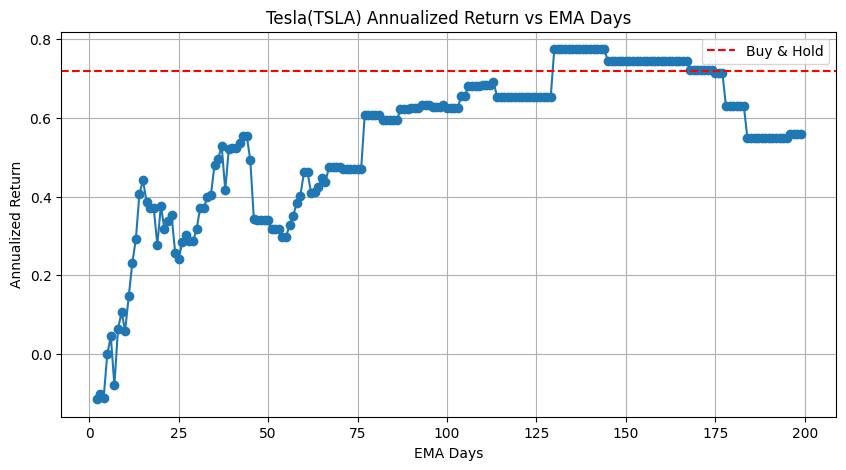

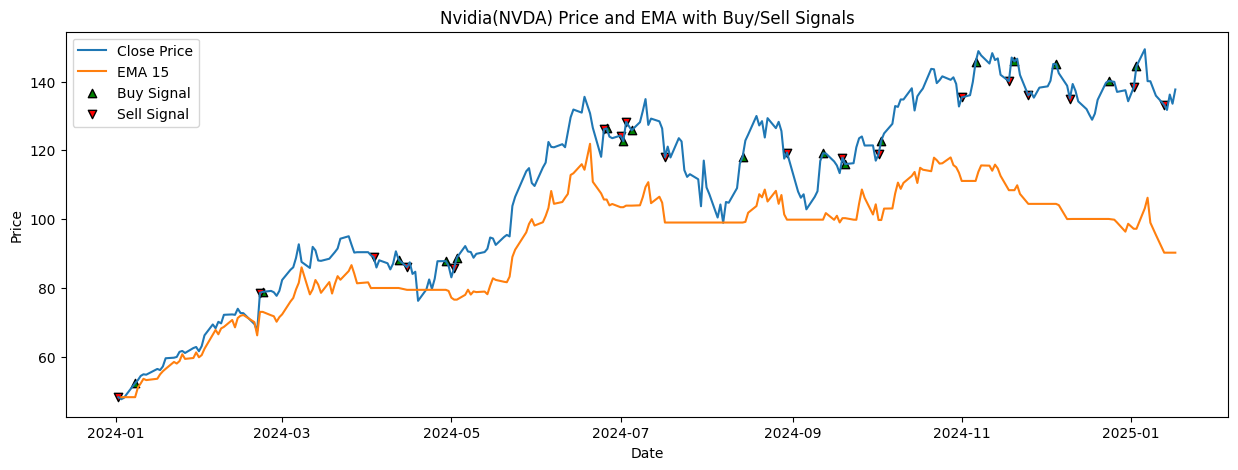

Best EMA days: 33


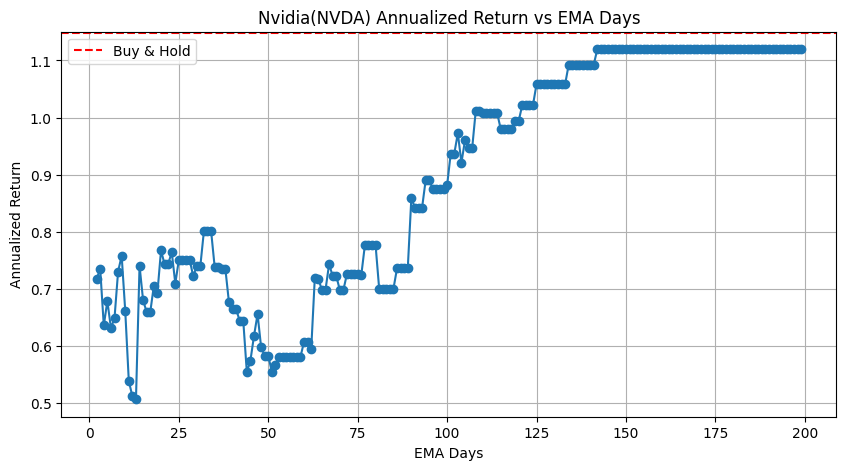

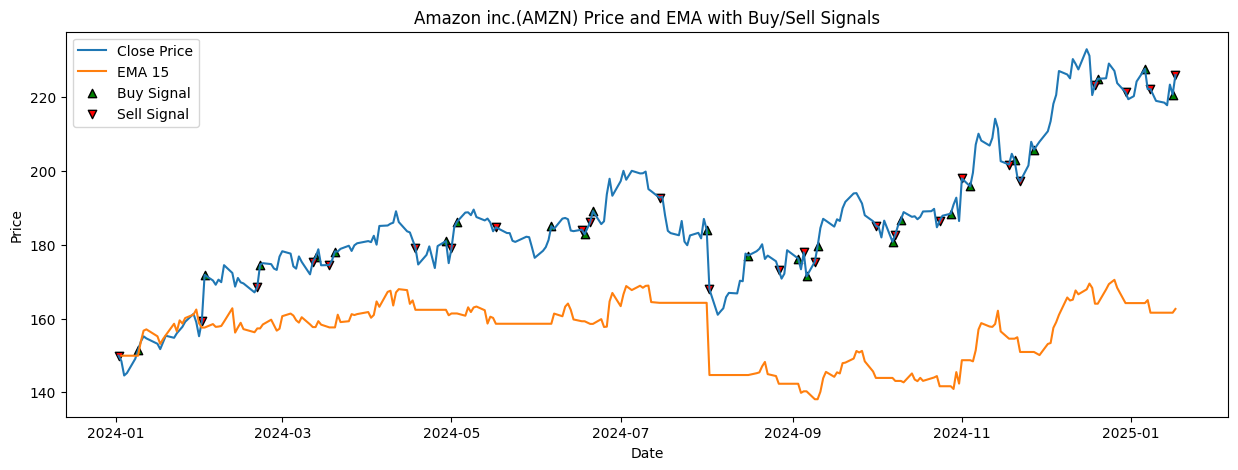

Best EMA days: 29


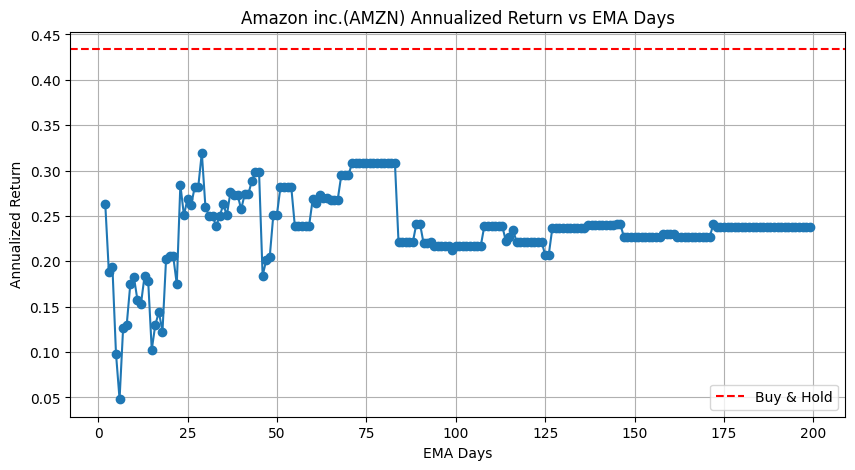

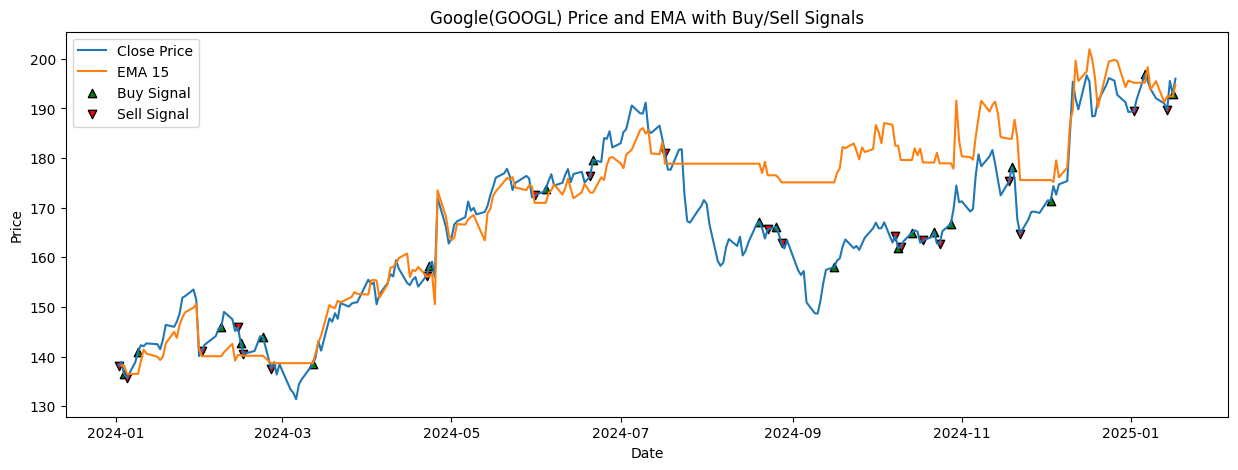

Best EMA days: 19


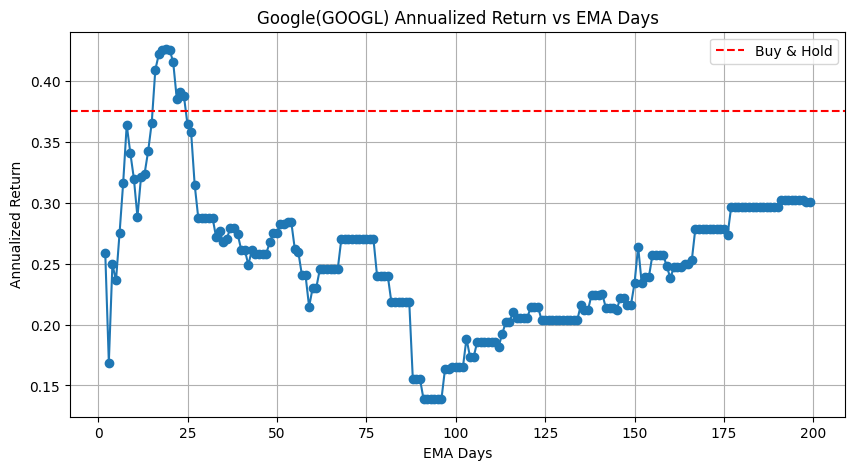

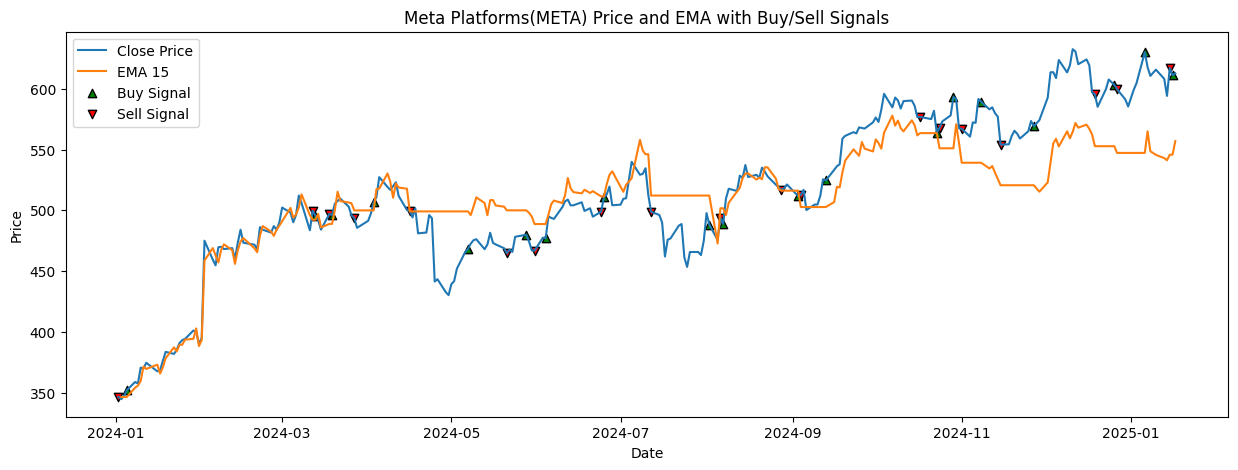

Best EMA days: 10


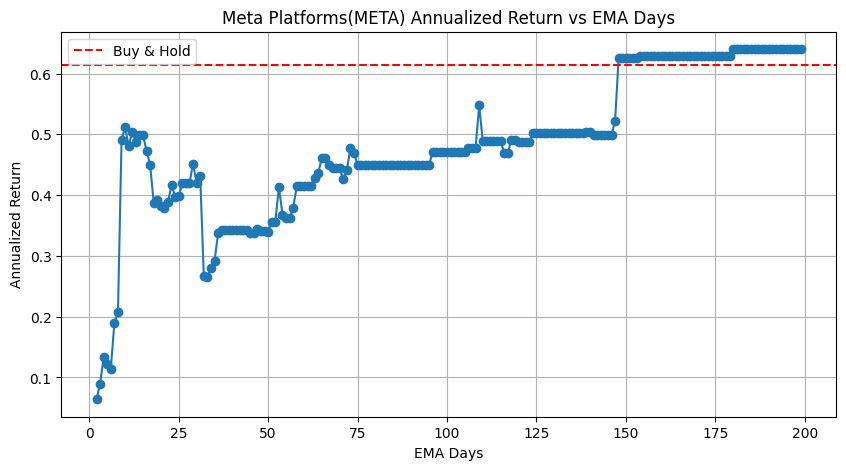

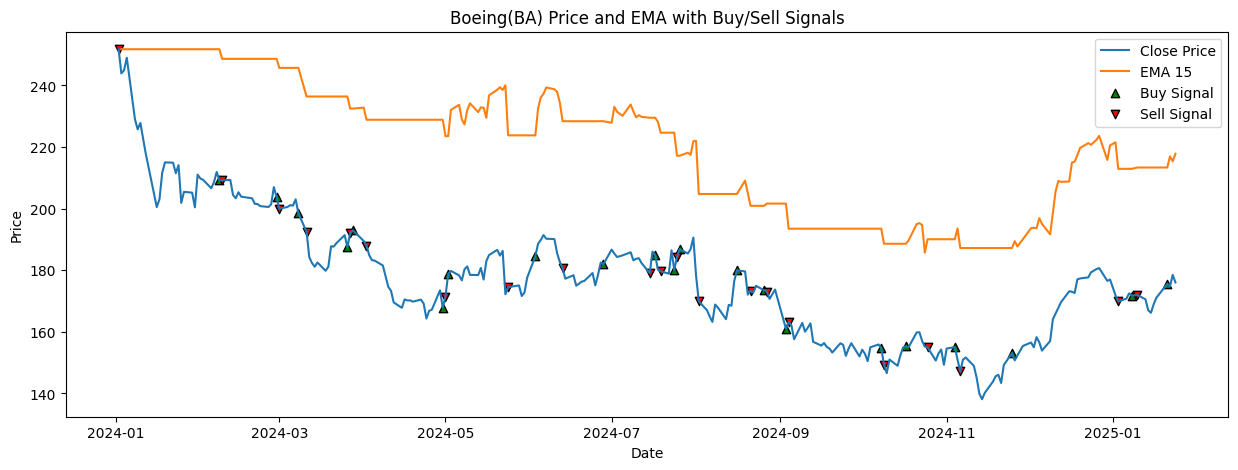

Best EMA days: 20


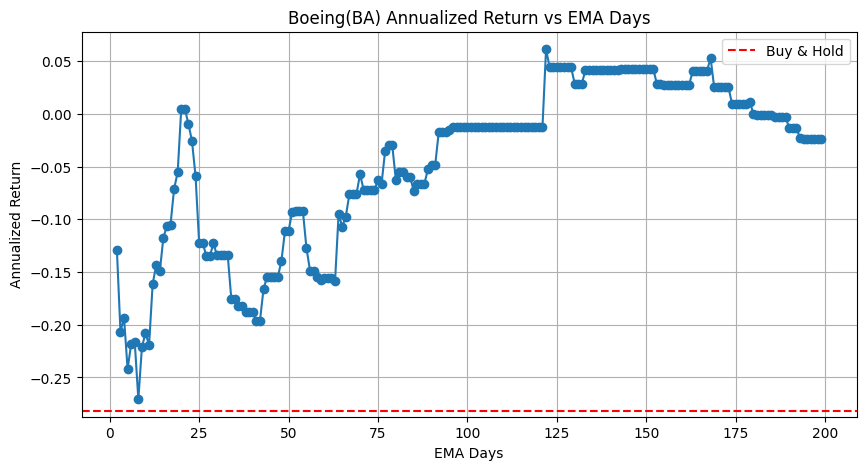

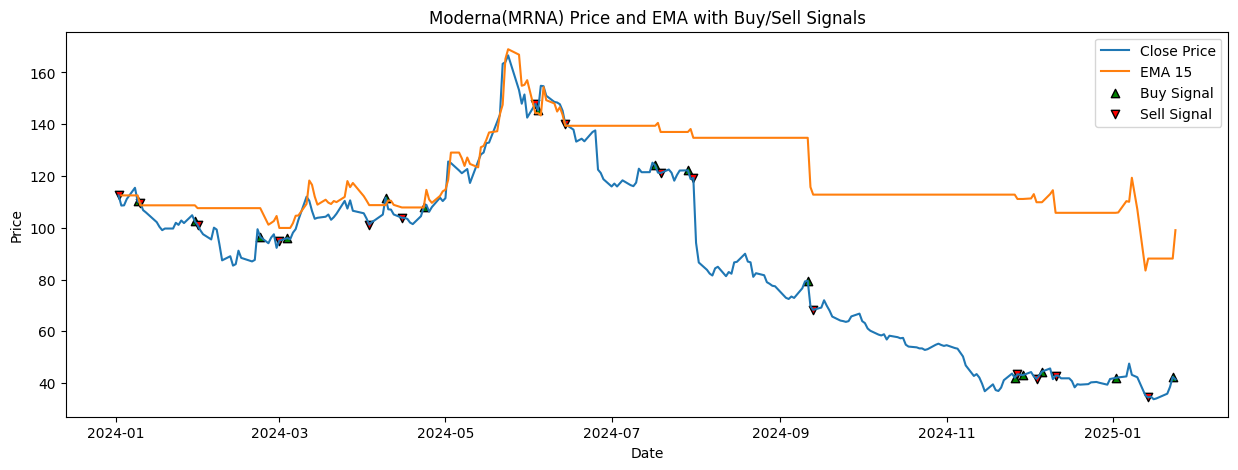

Best EMA days: 17


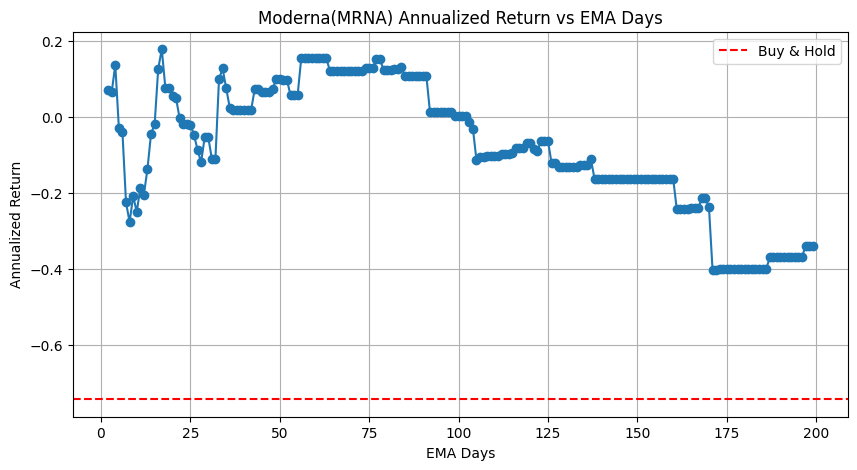

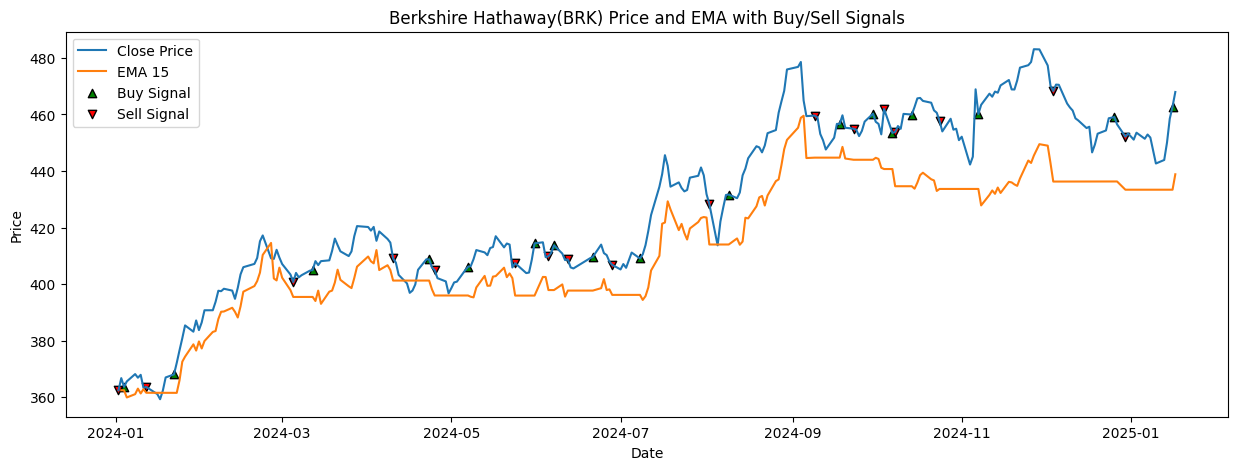

Best EMA days: 3


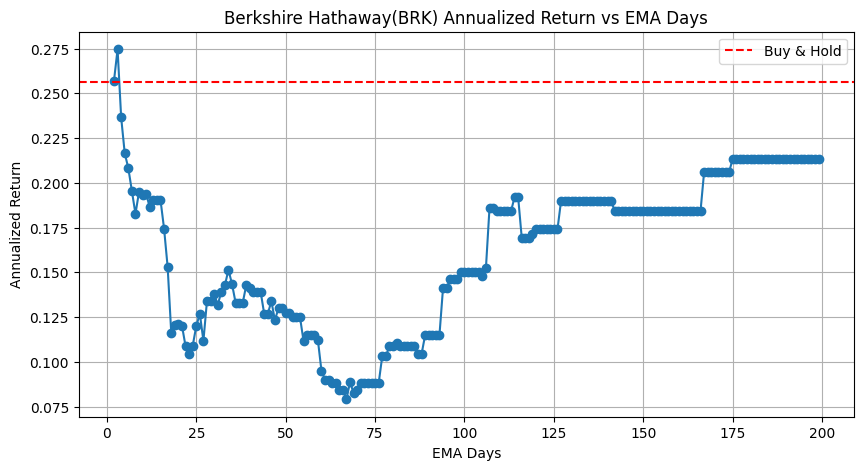

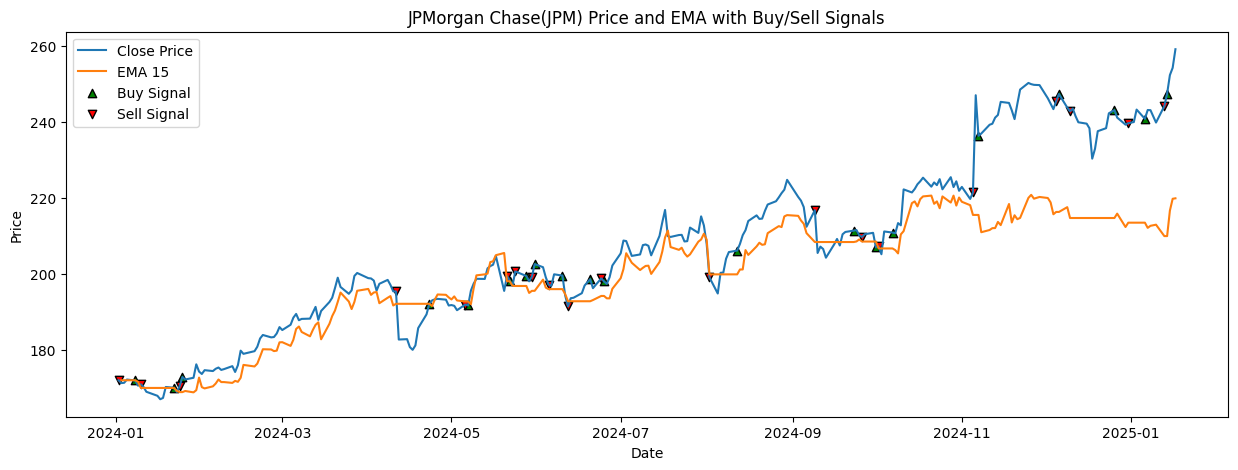

Best EMA days: 3


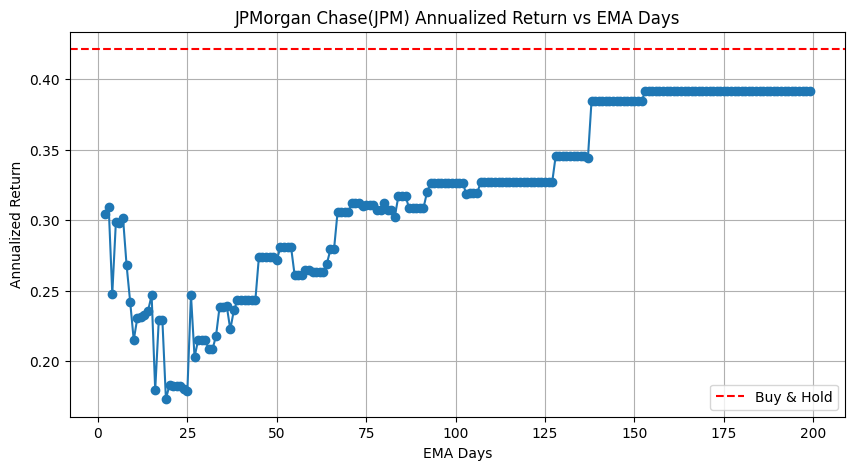

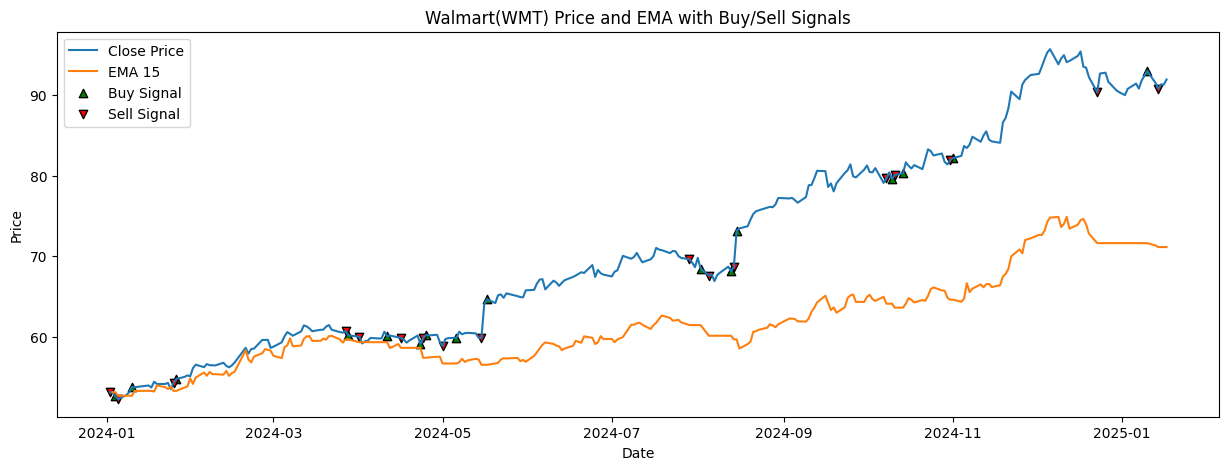

Best EMA days: 51


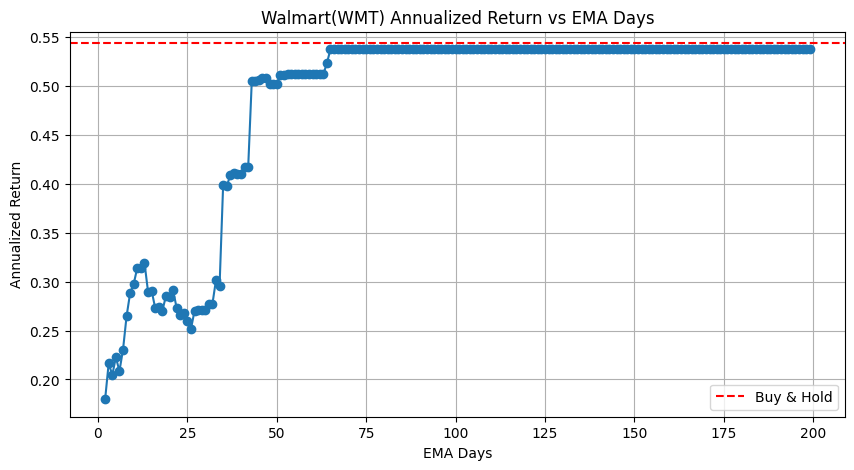

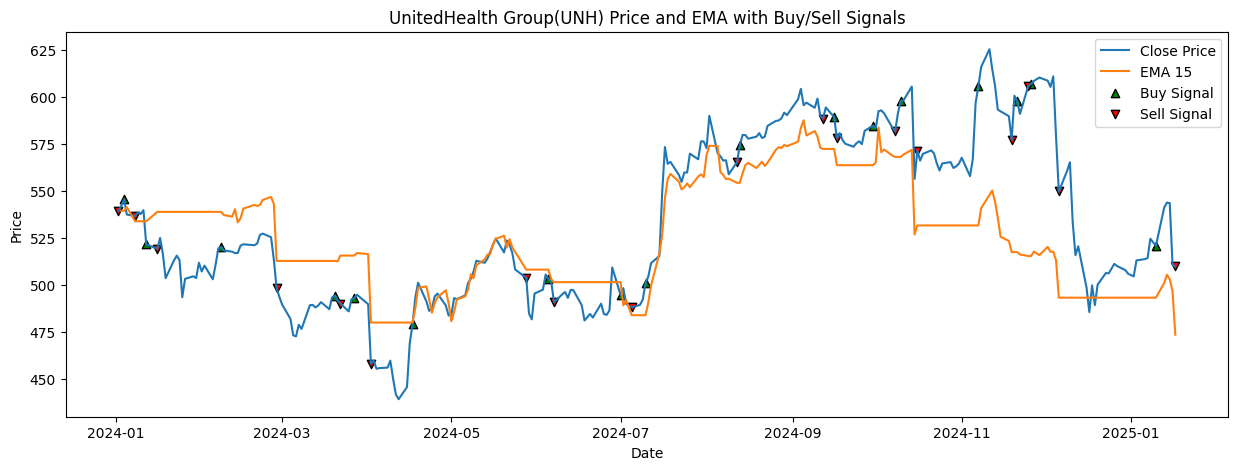

Best EMA days: 5


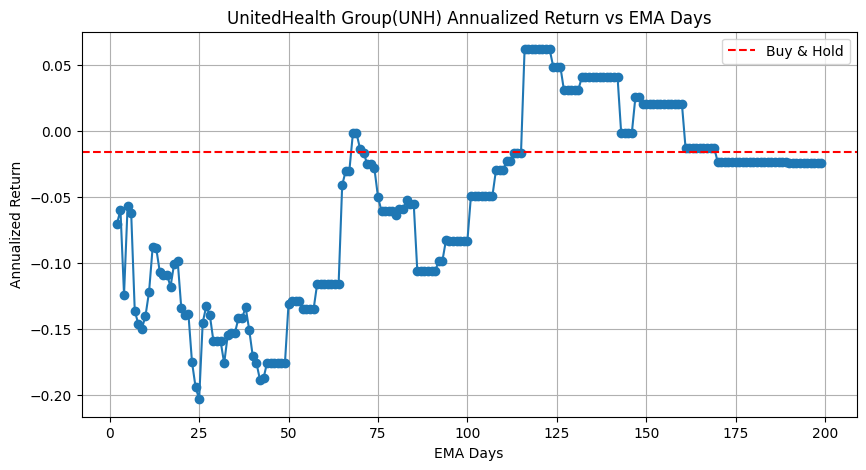

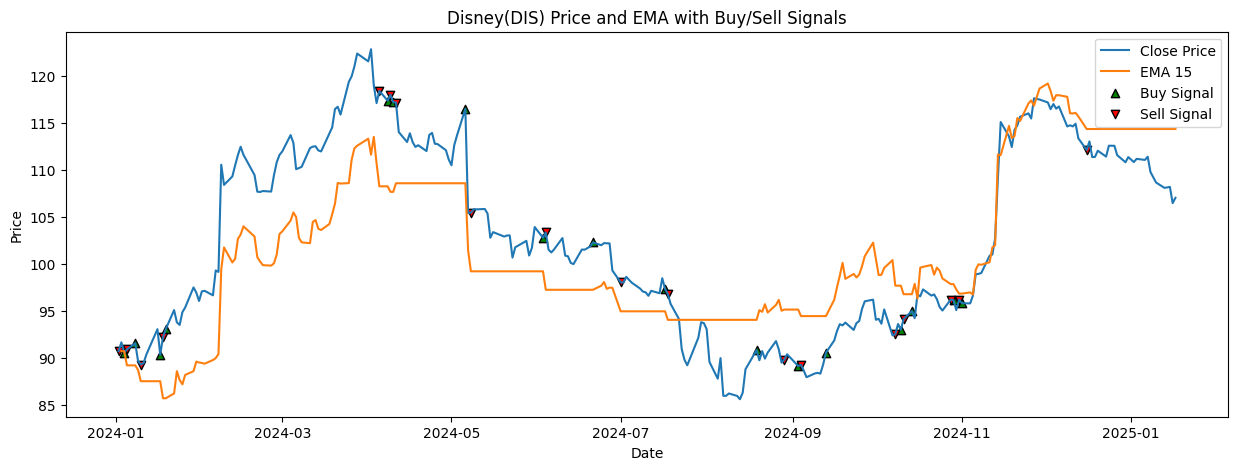

Best EMA days: 17


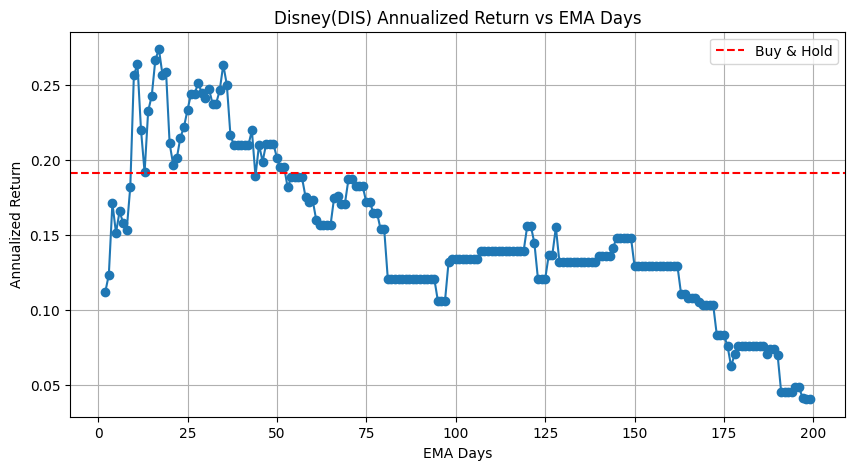

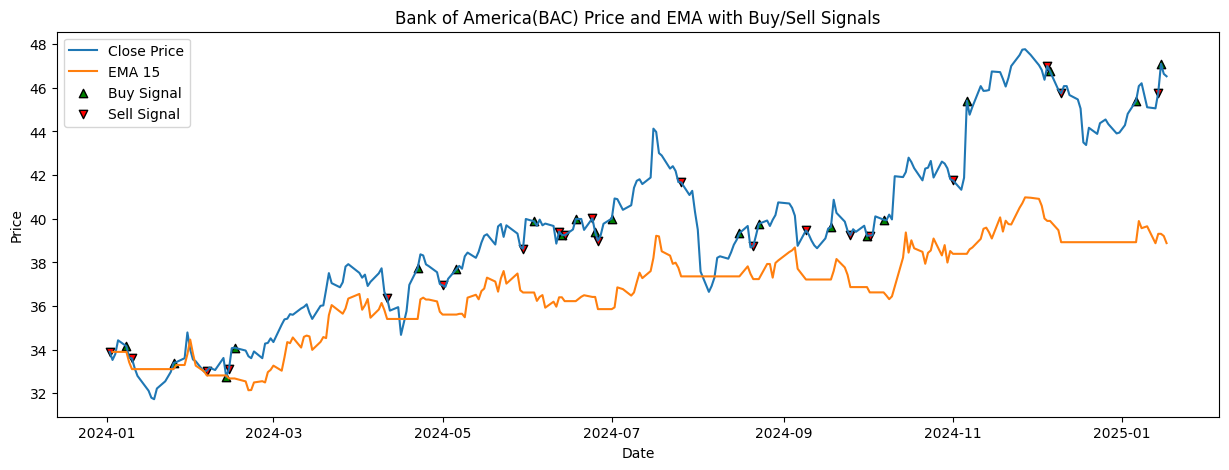

Best EMA days: 3


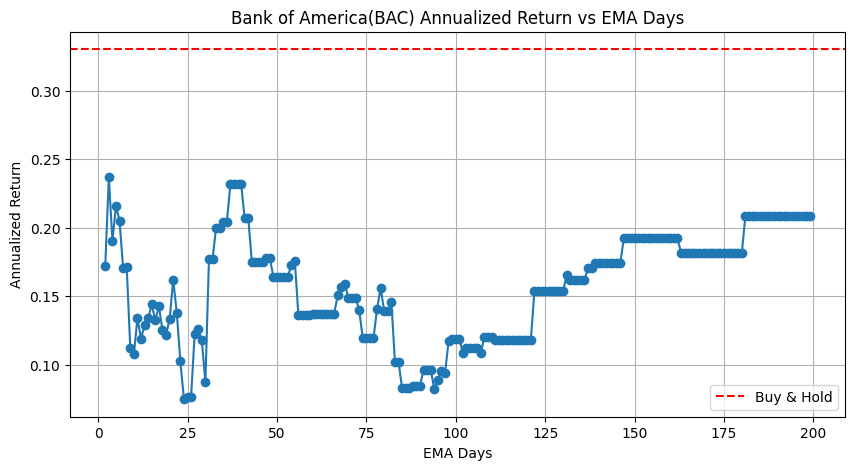

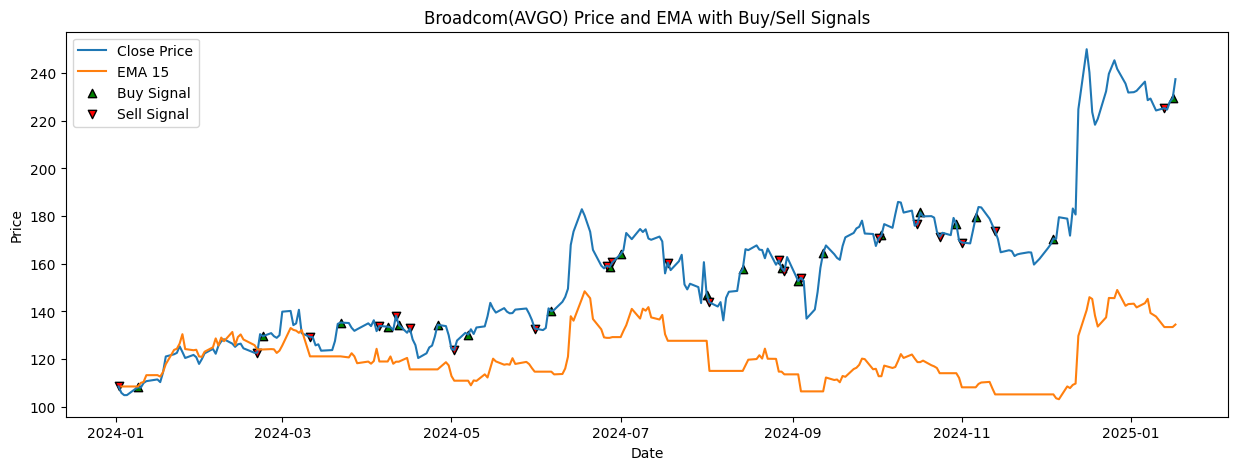

Best EMA days: 3


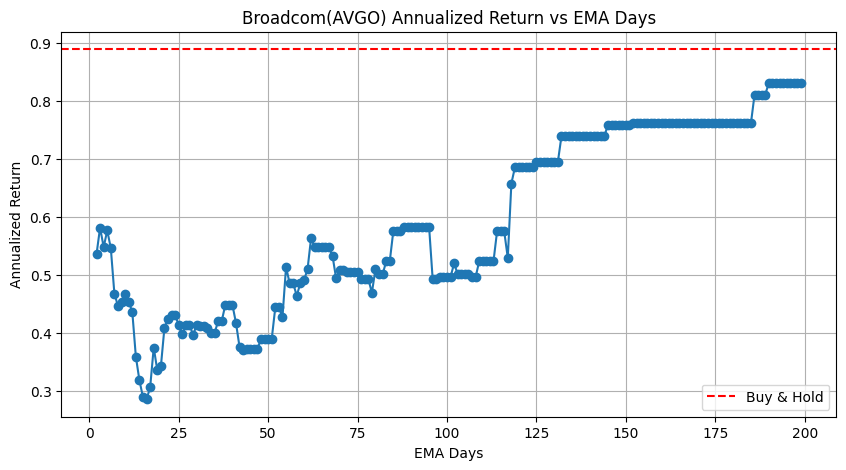

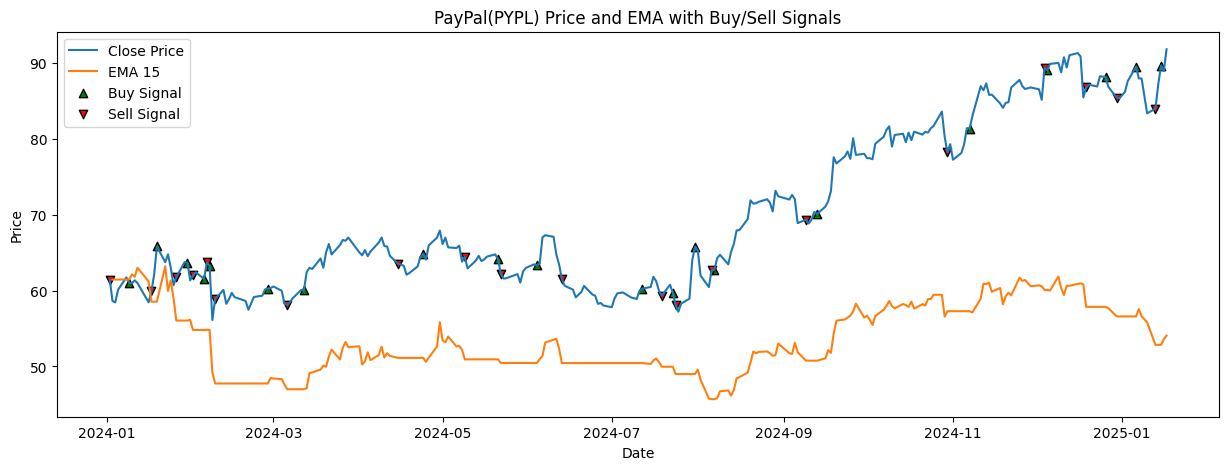

Best EMA days: 2


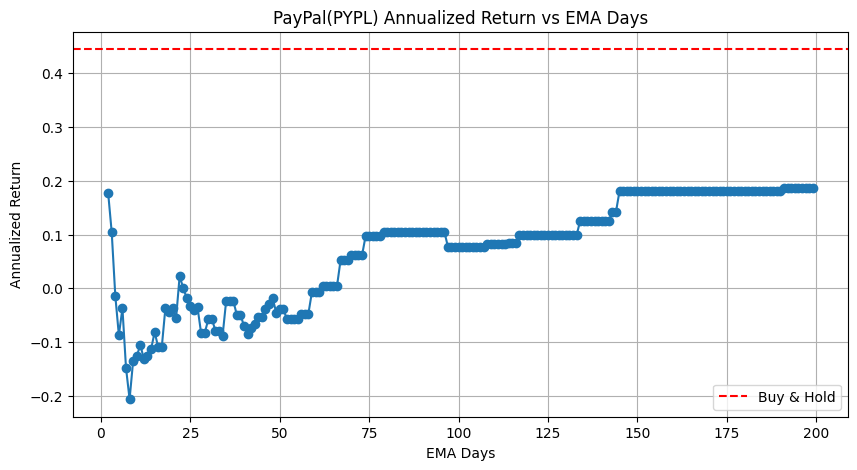

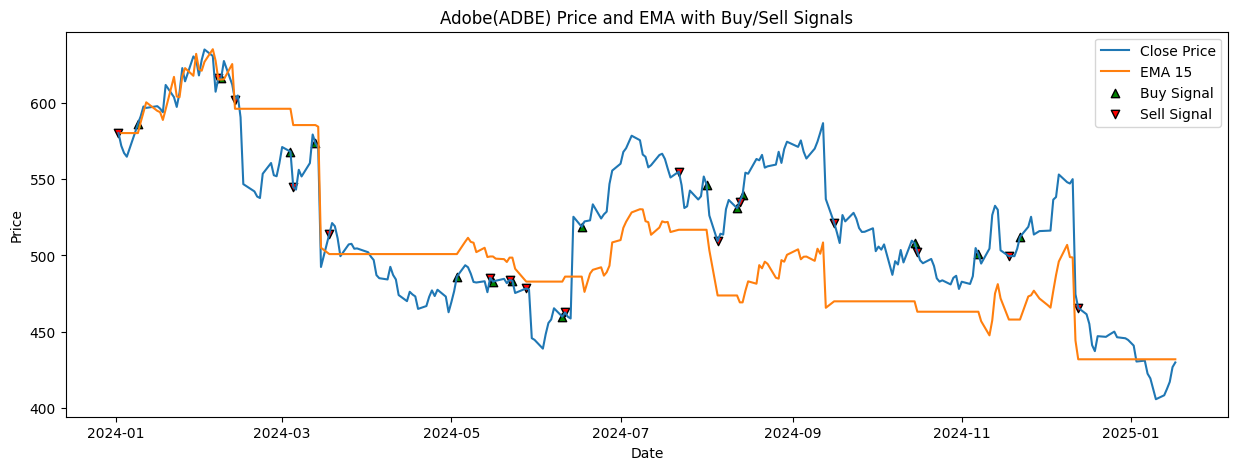

Best EMA days: 42


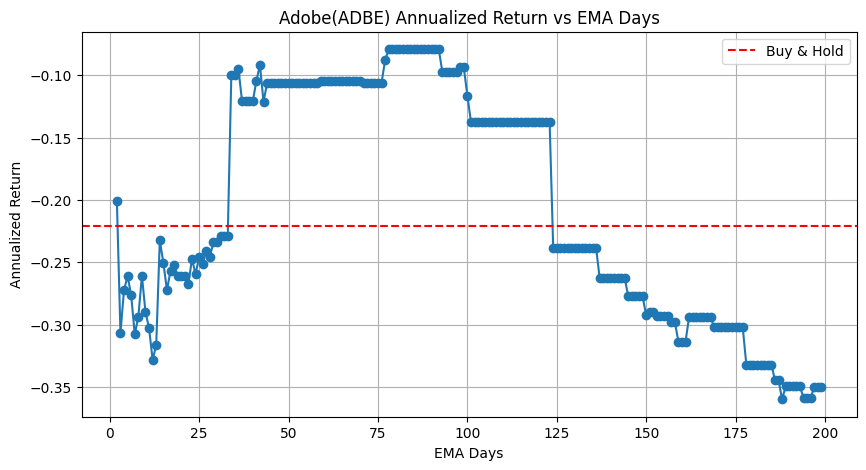

In [76]:
import pandas as pd
import os
import matplotlib.pyplot as plt

def calculate_ema(data, span):
    return data.ewm(span=span, adjust=False).mean()

def get_price_his(stock_id, country):
    path_price_his = f"{os.path.abspath(os.getcwd())}/history_data/{country}/stock_price/{stock_id}tech.csv"
    df_price_his = pd.read_csv(path_price_his, encoding="utf-8")
    df_price_his["Date"] = pd.to_datetime(df_price_his["Date"], format="%Y%m%d")
    # 讓時間在 2023-01-01 之後
    df_price_his = df_price_his[df_price_his["Date"] >= "2024-01-01"]
    return df_price_his

def run_ema(stock):
    stock_id = stock[0]
    stock_name = stock[1]
    country = stock[2]
    
    price_his = get_price_his(stock_id, country)
    # print(price_his.head())  # 顯示數據頭部

    ema_days = range(2, 200)
    annual_returns = []

    for i in ema_days:
        data = price_his.copy()
        data['Date'] = pd.to_datetime(data['Date'])  # 轉換日期格式
        data.set_index('Date', inplace=True)  # 設定日期為索引

        data['EMA'] = calculate_ema(data['Close'], span=i)  # 計算 i 日 EMA

        # 訊號判斷
        data['Signal'] = data['Close'].shift(1) > data['EMA'].shift(1)

        # 策略報酬
        data['Strategy_Return'] = data['Signal'].shift(1) * data['Open'].pct_change()

        # Buy & Hold 策略
        data['Buy_and_Hold'] = data['Close'].pct_change()

        # 計算累積報酬
        data['Cumulative_Strategy'] = (1 + data['Strategy_Return']).cumprod()
        data['Cumulative_Buy_Hold'] = (1 + data['Buy_and_Hold']).cumprod()

        # 計算年化報酬率
        days_per_year = 252
        buy_and_hold_return = price_his['Close'].pct_change().mean() * days_per_year

        annualized_return = data['Strategy_Return'].mean() * days_per_year
        annual_returns.append(annualized_return)

        if i == 15:
            plt.figure(figsize=(15, 5))
            plt.plot(data.index, data['Close'], label='Close Price', linestyle='-')
            plt.plot(data.index, data['Cumulative_Strategy']*float(data['Close'].iloc[0]), label=f'EMA {i}', linestyle='-')

            # 繪製進出場訊號
            buy_signals = data[(data['Signal'].astype(bool)) & ~(data['Signal'].shift(1).astype(bool))]
            sell_signals = data[(~data['Signal'].astype(bool)) & (data['Signal'].shift(1).astype(bool))]

            plt.scatter(buy_signals.index, buy_signals['Close'], marker='^', color='g', label='Buy Signal', alpha=1, edgecolors='black')
            plt.scatter(sell_signals.index, sell_signals['Close'], marker='v', color='r', label='Sell Signal', alpha=1, edgecolors='black')

            plt.legend()
            plt.title(f'{stock_name}({stock_id}) Price and EMA with Buy/Sell Signals')
            plt.xlabel('Date')
            plt.ylabel('Price')
            plt.show()

    # print best index of annual return
    best_index = annual_returns.index(max(annual_returns[:50]))
    print(f"Best EMA days: {ema_days[best_index]}")
    
    # 繪製 EMA 日數與年化報酬率的關係圖
    plt.figure(figsize=(10, 5))
    plt.plot(ema_days, annual_returns, marker='o', linestyle='-')
    plt.axhline(y=buy_and_hold_return, color='r', linestyle='--', label='Buy & Hold')  # Buy & Hold 年化報酬率
    plt.title(f'{stock_name}({stock_id}) Annualized Return vs EMA Days')
    plt.xlabel('EMA Days')
    plt.ylabel('Annualized Return')
    plt.grid()
    plt.legend()
    plt.show()
    
stocks = [
    ["spx", "S&P 500", "us"],
    ["AAPL", "Apple Inc.", "us"],
    ["MSFT", "Microsoft", "us"],
    ["TSLA", "Tesla", "us"],
    ["NVDA", "Nvidia", "us"],
    ["AMZN", "Amazon inc.", "us"],
    ["GOOGL", "Google", "us"],
    ["META", "Meta Platforms", "us"],
    ["BA", "Boeing", "us"],
    ["MRNA", "Moderna", "us"],
    ["BRK", "Berkshire Hathaway", "us"],
    ["JPM", "JPMorgan Chase", "us"],
    ["WMT", "Walmart", "us"],
    ["UNH", "UnitedHealth Group", "us"],
    ["DIS", "Disney", "us"],
    ["BAC", "Bank of America", "us"],
    ["AVGO", "Broadcom", "us"],
    ["PYPL", "PayPal", "us"],
    ["ADBE", "Adobe", "us"],
]

for stock in stocks:
    stock_id = stock[0]
    stock_name = stock[1]
    country = stock[2]
    path_price_his = f"{os.path.abspath(os.getcwd())}/history_data/{country}/stock_price/{stock_id}tech.csv"
    if not os.path.exists(path_price_his):
        print(f"File not found: {path_price_his}")
        continue
    run_ema(stock)